# ColBERT v2: Understanding Late Interaction Retrieval
*AI Tinkerers Presentation*

---

## 1. What is ColBERT?

**ColBERT** = **C**ontextualized **L**ate Interaction **o**ver **BERT**

### Traditional Dense Retrieval vs ColBERT

/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/1655887730.py:85: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/1655887730.py:85: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/luvsuneja/Documents/repos/advanced-rag-experimentation/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/luvsuneja/Documents/repos/advanced-rag-experimentation/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


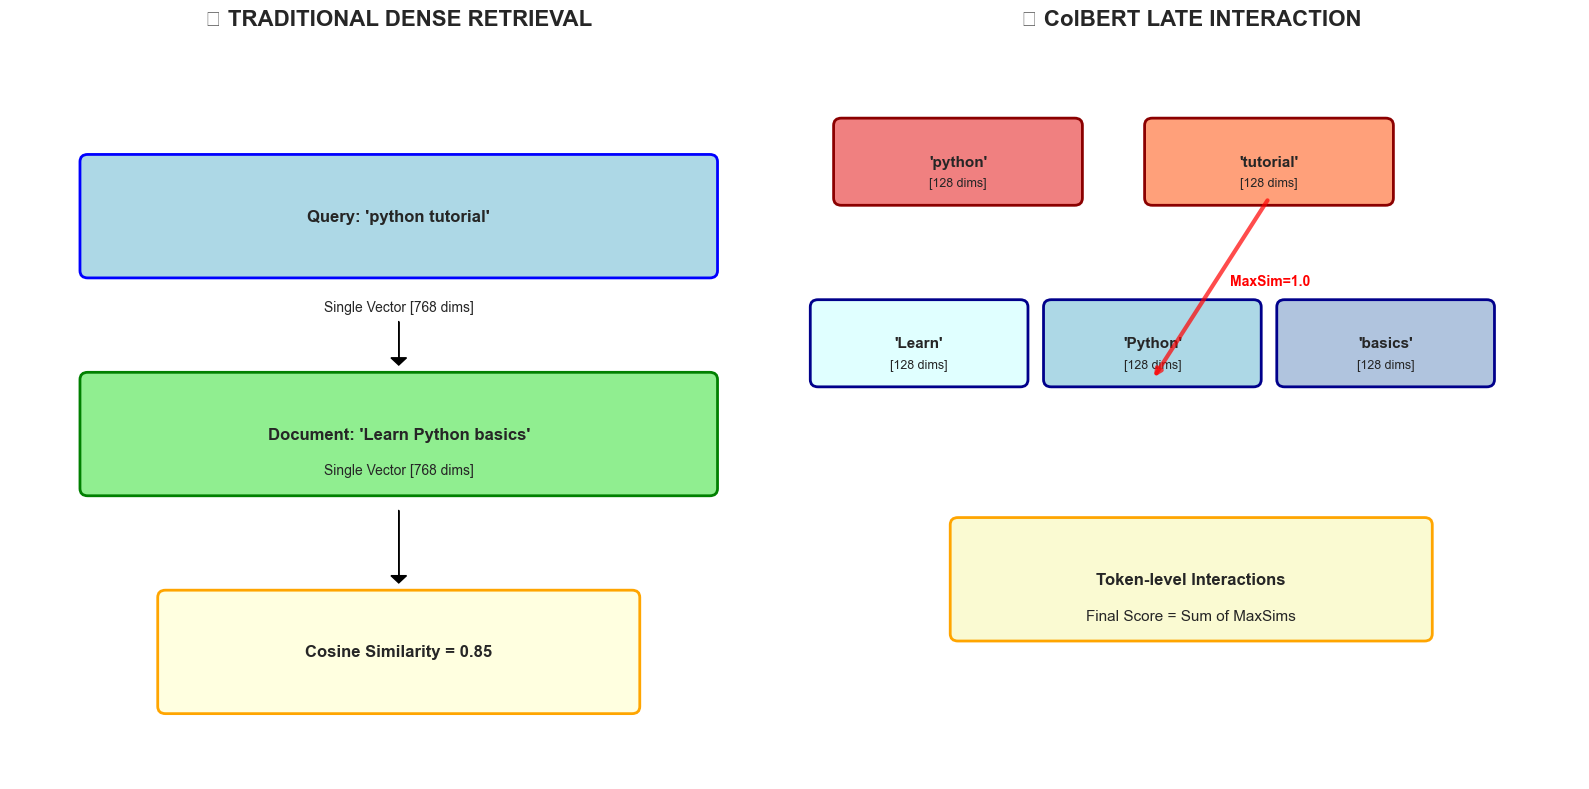

💡 KEY INSIGHT: ColBERT captures fine-grained token-level semantic relationships!
   Dense retrieval loses information by compressing everything into one vector.


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

# Set up the plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Create visual comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Traditional Dense Retrieval Visualization
ax1.set_title("🔵 TRADITIONAL DENSE RETRIEVAL", fontsize=16, fontweight='bold', pad=20)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)

# Query representation
query_box = FancyBboxPatch((1, 7), 8, 1.5, boxstyle="round,pad=0.1", 
                           facecolor='lightblue', edgecolor='blue', linewidth=2)
ax1.add_patch(query_box)
ax1.text(5, 7.75, "Query: 'python tutorial'", ha='center', va='center', fontsize=12, fontweight='bold')
ax1.text(5, 6.5, "Single Vector [768 dims]", ha='center', va='center', fontsize=10)

# Document representation
doc_box = FancyBboxPatch((1, 4), 8, 1.5, boxstyle="round,pad=0.1", 
                         facecolor='lightgreen', edgecolor='green', linewidth=2)
ax1.add_patch(doc_box)
ax1.text(5, 4.75, "Document: 'Learn Python basics'", ha='center', va='center', fontsize=12, fontweight='bold')
ax1.text(5, 4.25, "Single Vector [768 dims]", ha='center', va='center', fontsize=10)

# Similarity computation
sim_box = FancyBboxPatch((2, 1), 6, 1.5, boxstyle="round,pad=0.1", 
                         facecolor='lightyellow', edgecolor='orange', linewidth=2)
ax1.add_patch(sim_box)
ax1.text(5, 1.75, "Cosine Similarity = 0.85", ha='center', va='center', fontsize=12, fontweight='bold')

# Arrows
ax1.arrow(5, 6.3, 0, -0.5, head_width=0.2, head_length=0.1, fc='black', ec='black')
ax1.arrow(5, 3.7, 0, -0.9, head_width=0.2, head_length=0.1, fc='black', ec='black')

ax1.axis('off')

# ColBERT Late Interaction Visualization
ax2.set_title("🟢 ColBERT LATE INTERACTION", fontsize=16, fontweight='bold', pad=20)
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)

# Query tokens
token_colors = ['lightcoral', 'lightsalmon']
query_tokens = ['python', 'tutorial']
for i, token in enumerate(query_tokens):
    token_box = FancyBboxPatch((0.5 + i*4, 8), 3, 1, boxstyle="round,pad=0.1", 
                               facecolor=token_colors[i], edgecolor='darkred', linewidth=2)
    ax2.add_patch(token_box)
    ax2.text(2 + i*4, 8.5, f"'{token}'", ha='center', va='center', fontsize=11, fontweight='bold')
    ax2.text(2 + i*4, 8.2, "[128 dims]", ha='center', va='center', fontsize=9)

# Document tokens
doc_token_colors = ['lightcyan', 'lightblue', 'lightsteelblue']
doc_tokens = ['Learn', 'Python', 'basics']
for i, token in enumerate(doc_tokens):
    token_box = FancyBboxPatch((0.2 + i*3, 5.5), 2.6, 1, boxstyle="round,pad=0.1", 
                               facecolor=doc_token_colors[i], edgecolor='darkblue', linewidth=2)
    ax2.add_patch(token_box)
    ax2.text(1.5 + i*3, 6, f"'{token}'", ha='center', va='center', fontsize=11, fontweight='bold')
    ax2.text(1.5 + i*3, 5.7, "[128 dims]", ha='center', va='center', fontsize=9)

# MaxSim interaction arrows (simplified)
# Show key interactions
ax2.annotate('', xy=(4.5, 5.5), xytext=(6, 8), 
             arrowprops=dict(arrowstyle='->', lw=3, color='red', alpha=0.7))
ax2.text(5.5, 6.8, 'MaxSim=1.0', fontsize=10, fontweight='bold', color='red')

# Final score
score_box = FancyBboxPatch((2, 2), 6, 1.5, boxstyle="round,pad=0.1", 
                           facecolor='lightgoldenrodyellow', edgecolor='orange', linewidth=2)
ax2.add_patch(score_box)
ax2.text(5, 2.75, "Token-level Interactions", ha='center', va='center', fontsize=12, fontweight='bold')
ax2.text(5, 2.25, "Final Score = Sum of MaxSims", ha='center', va='center', fontsize=11)

ax2.axis('off')

plt.tight_layout()
plt.show()

print("💡 KEY INSIGHT: ColBERT captures fine-grained token-level semantic relationships!")
print("   Dense retrieval loses information by compressing everything into one vector.")

### Key Insight: Token-level matching captures fine-grained semantic relationships!

In [26]:
# Demonstrate MaxSim calculation
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Query tokens
python_token = np.array([0.2, 0.8, 0.1, 0.9])
tutorial_token = np.array([0.1, 0.9, 0.3, 0.7])

# Document tokens
learn_token = np.array([0.4, 0.6, 0.2, 0.5])
Python_token = np.array([0.2, 0.8, 0.1, 0.9])  # Notice: same as query "python"!
basics_token = np.array([0.3, 0.5, 0.4, 0.6])

doc_tokens = [learn_token, Python_token, basics_token]
doc_names = ['Learn', 'Python', 'basics']

print("ColBERT MaxSim Calculation:")
print("\n'python' query token vs all document tokens:")
python_similarities = []
for i, doc_token in enumerate(doc_tokens):
    sim = cosine_similarity(python_token, doc_token)
    python_similarities.append(sim)
    print(f"  vs '{doc_names[i]}': {sim:.3f}")

python_maxsim = max(python_similarities)
print(f"MaxSim for 'python': {python_maxsim:.3f}")

print("\n'tutorial' query token vs all document tokens:")
tutorial_similarities = []
for i, doc_token in enumerate(doc_tokens):
    sim = cosine_similarity(tutorial_token, doc_token)
    tutorial_similarities.append(sim)
    print(f"  vs '{doc_names[i]}': {sim:.3f}")

tutorial_maxsim = max(tutorial_similarities)
print(f"MaxSim for 'tutorial': {tutorial_maxsim:.3f}")

total_score = python_maxsim + tutorial_maxsim
print(f"\n🎯 Final ColBERT Score: {python_maxsim:.3f} + {tutorial_maxsim:.3f} = {total_score:.3f}")

ColBERT MaxSim Calculation:

'python' query token vs all document tokens:
  vs 'Learn': 0.934
  vs 'Python': 1.000
  vs 'basics': 0.916
MaxSim for 'python': 1.000

'tutorial' query token vs all document tokens:
  vs 'Learn': 0.930
  vs 'Python': 0.966
  vs 'basics': 0.930
MaxSim for 'tutorial': 0.966

🎯 Final ColBERT Score: 1.000 + 0.966 = 1.966


---

## 2. ColBERT v1 Problems

### Problem 1: Storage Explosion 💥

/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/1226520099.py:98: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/1226520099.py:98: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/1226520099.py:98: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/1226520099.py:98: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/1226520099.py:98: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) Arial.
  plt.tight_layout()
/Users/luvsuneja/Documents/repos/advanced-rag-experimentation/.venv/lib/python3.12/site-packages/IPython/c

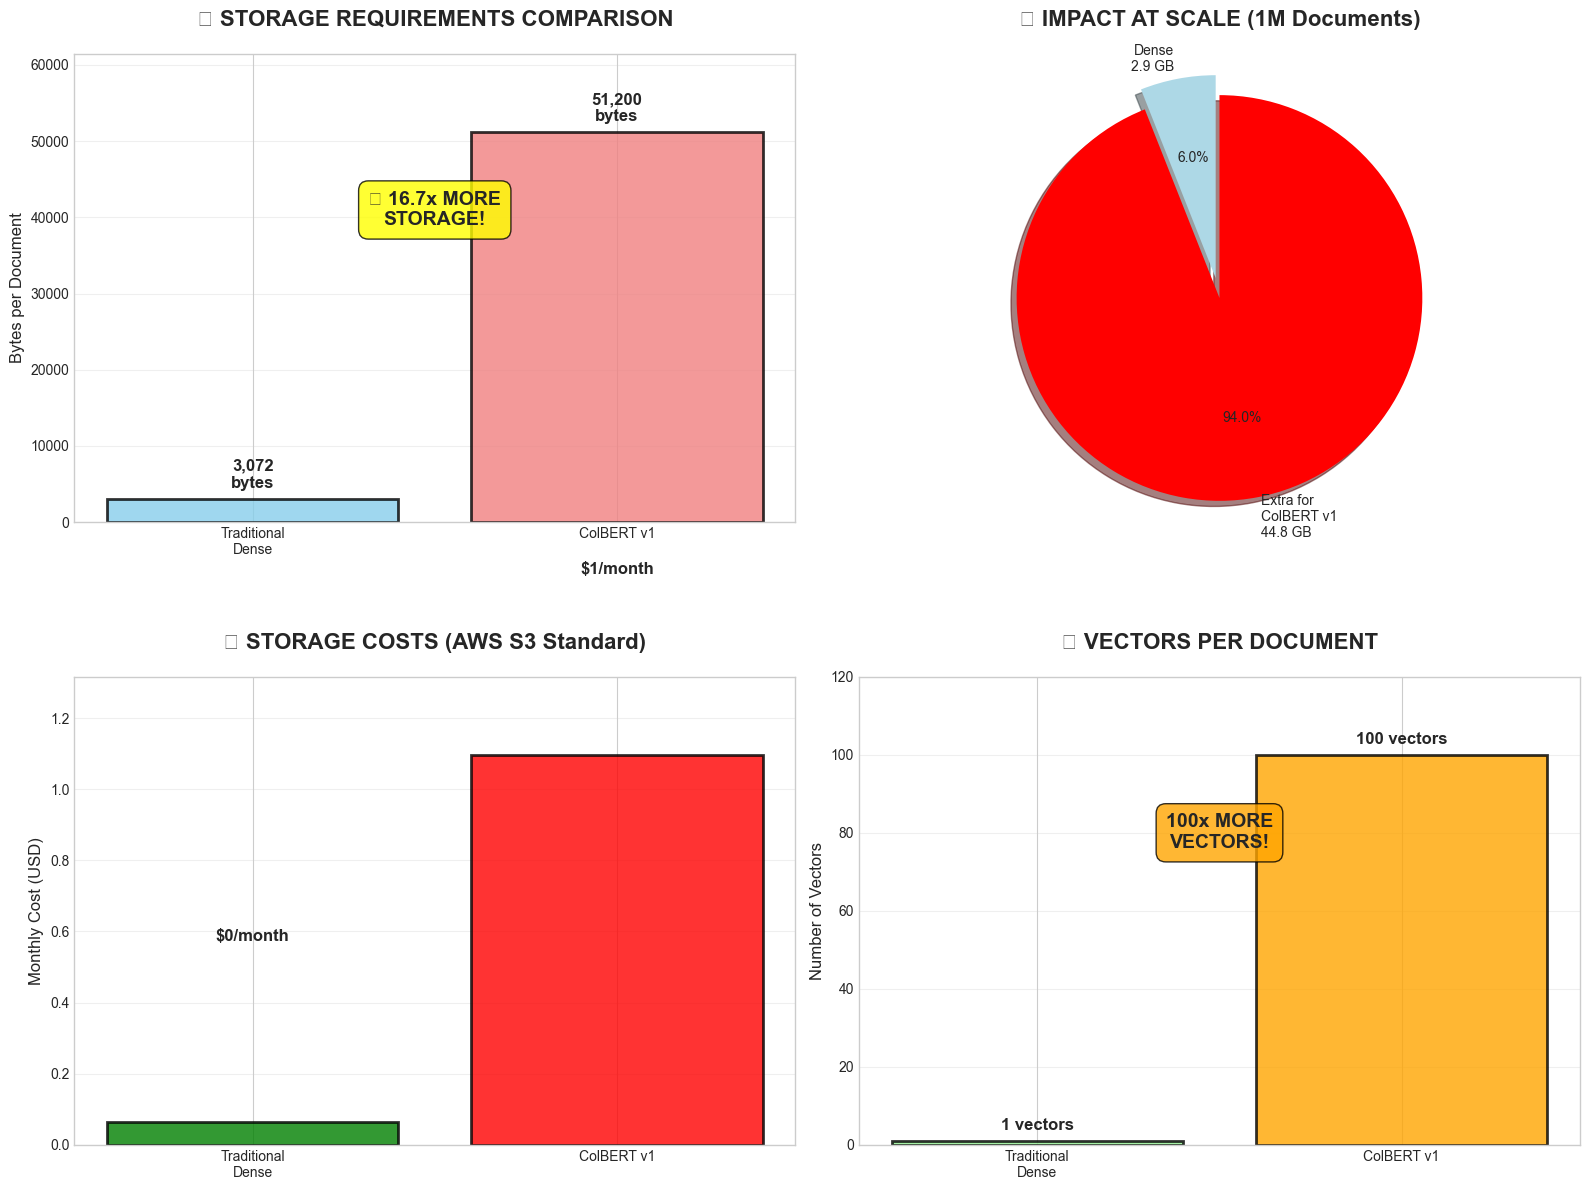

🔥 THE STORAGE PROBLEM:
   💾 ColBERT v1: 16.7x more storage than dense retrieval
   💰 Monthly cost: $1 vs $0
   🏢 For enterprise: This could be $1000s per month extra!
   🚨 SOLUTION NEEDED: ColBERT v2's compression innovations


In [15]:
# Create dramatic storage comparison visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Storage explosion visualization with icons
ax1.set_title("💾 STORAGE REQUIREMENTS COMPARISON", fontsize=16, fontweight='bold', pad=20)

# Traditional dense retrieval
dense_vectors_per_doc = 1
dense_vector_size = 768
dense_bytes_per_doc = dense_vectors_per_doc * dense_vector_size * 4

# ColBERT v1
colbert_tokens_per_doc = 100
colbert_vector_size = 128
colbert_bytes_per_doc = colbert_tokens_per_doc * colbert_vector_size * 4

# Create visual representation with bars
models = ['Traditional\nDense', 'ColBERT v1']
bytes_per_doc = [dense_bytes_per_doc, colbert_bytes_per_doc]
colors = ['skyblue', 'lightcoral']

bars = ax1.bar(models, bytes_per_doc, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

# Add value labels with better formatting
for bar, value in zip(bars, bytes_per_doc):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 1000, 
             f'{value:,}\nbytes', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax1.set_ylabel('Bytes per Document', fontsize=12)
ax1.set_ylim(0, max(bytes_per_doc) * 1.2)
ax1.grid(axis='y', alpha=0.3)

# Add explosion annotation
explosion_factor = colbert_bytes_per_doc / dense_bytes_per_doc
ax1.text(0.5, max(bytes_per_doc) * 0.8, f'💥 {explosion_factor:.1f}x MORE\nSTORAGE!', 
         ha='center', va='center', fontsize=14, fontweight='bold', 
         bbox=dict(boxstyle="round,pad=0.5", facecolor='yellow', alpha=0.8))

# Scale impact visualization
ax2.set_title("📊 IMPACT AT SCALE (1M Documents)", fontsize=16, fontweight='bold', pad=20)

num_docs = 1_000_000
dense_total_gb = (dense_bytes_per_doc * num_docs) / (1024**3)
colbert_total_gb = (colbert_bytes_per_doc * num_docs) / (1024**3)

# Create pie charts for visual impact
sizes = [dense_total_gb, colbert_total_gb - dense_total_gb]
labels = [f'Dense\n{dense_total_gb:.1f} GB', f'Extra for\nColBERT v1\n{colbert_total_gb - dense_total_gb:.1f} GB']
colors = ['lightblue', 'red']
explode = (0, 0.1)  # explode the second slice

wedges, texts, autotexts = ax2.pie(sizes, labels=labels, colors=colors, explode=explode, 
                                   autopct='%1.1f%%', shadow=True, startangle=90)
ax2.axis('equal')

# Storage cost visualization
ax3.set_title("💰 STORAGE COSTS (AWS S3 Standard)", fontsize=16, fontweight='bold', pad=20)

# Approximate costs ($0.023 per GB per month)
cost_per_gb_month = 0.023
dense_cost_month = dense_total_gb * cost_per_gb_month
colbert_cost_month = colbert_total_gb * cost_per_gb_month

costs = [dense_cost_month, colbert_cost_month]
cost_bars = ax3.bar(models, costs, color=['green', 'red'], alpha=0.8, edgecolor='black', linewidth=2)

for bar, cost in zip(cost_bars, costs):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height + 0.5, 
             f'${cost:.0f}/month', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax3.set_ylabel('Monthly Cost (USD)', fontsize=12)
ax3.set_ylim(0, max(costs) * 1.2)
ax3.grid(axis='y', alpha=0.3)

# Vector count visualization
ax4.set_title("🔢 VECTORS PER DOCUMENT", fontsize=16, fontweight='bold', pad=20)

vector_counts = [1, 100]
vector_bars = ax4.bar(models, vector_counts, color=['lightgreen', 'orange'], 
                      alpha=0.8, edgecolor='black', linewidth=2)

for bar, count in zip(vector_bars, vector_counts):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2, height + 2, 
             f'{count} vectors', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax4.set_ylabel('Number of Vectors', fontsize=12)
ax4.set_ylim(0, 120)
ax4.grid(axis='y', alpha=0.3)

# Add dramatic text annotation
ax4.text(0.5, 80, '100x MORE\nVECTORS!', ha='center', va='center', 
         fontsize=14, fontweight='bold', 
         bbox=dict(boxstyle="round,pad=0.5", facecolor='orange', alpha=0.8))

plt.tight_layout()
plt.show()

print("🔥 THE STORAGE PROBLEM:")
print(f"   💾 ColBERT v1: {explosion_factor:.1f}x more storage than dense retrieval")
print(f"   💰 Monthly cost: ${colbert_cost_month:.0f} vs ${dense_cost_month:.0f}")
print(f"   🏢 For enterprise: This could be $1000s per month extra!")
print("   🚨 SOLUTION NEEDED: ColBERT v2's compression innovations")

### Problem 2: Noisy Training Data 🗑️

In [16]:
print("🗑️ EXAMPLES OF NOISY TRAINING DATA")
print()

print("❌ Bad Auto-Generated Labels:")
print()

print("1. BM25 Keyword Matching:")
print("   Query: 'python tutorial'")
print("   Document: 'Basic machine for learning disabled children'")
print("   BM25 says: RELEVANT (matches 'basic' and 'learning')")
print("   Reality: Completely irrelevant!")
print()

print("2. Click-through Data:")
print("   User searches: 'machine learning tutorial'")
print("   Clicks on: 'Java vs Python comparison'")
print("   Leaves immediately (wrong result)")
print("   System learns: 'Java article relevant to ML tutorial'")
print()

print("3. Weak Supervision:")
print("   Old retrieval model says: Document X is relevant")
print("   Train new model on these labels")
print("   Result: Inherit all the old model's mistakes!")
print()

print("📈 Scale of the Problem:")
print(f"   • Need {10_000_000:,} training examples for good performance")
print(f"   • Manual labeling cost: ${10_000_000:,} at $1 per label")
print(f"   • Auto-labeling: ~30% wrong labels")
print(f"   • Result: ColBERT v1 learned from garbage data!")

🗑️ EXAMPLES OF NOISY TRAINING DATA

❌ Bad Auto-Generated Labels:

1. BM25 Keyword Matching:
   Query: 'python tutorial'
   Document: 'Basic machine for learning disabled children'
   BM25 says: RELEVANT (matches 'basic' and 'learning')
   Reality: Completely irrelevant!

2. Click-through Data:
   User searches: 'machine learning tutorial'
   Clicks on: 'Java vs Python comparison'
   Leaves immediately (wrong result)
   System learns: 'Java article relevant to ML tutorial'

3. Weak Supervision:
   Old retrieval model says: Document X is relevant
   Train new model on these labels
   Result: Inherit all the old model's mistakes!

📈 Scale of the Problem:
   • Need 10,000,000 training examples for good performance
   • Manual labeling cost: $10,000,000 at $1 per label
   • Auto-labeling: ~30% wrong labels
   • Result: ColBERT v1 learned from garbage data!


---

## 3. ColBERT v2 Solutions

### Innovation 1: Residual Compression

**The Idea:** Use clustering + quantization to compress token embeddings

/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/3162350501.py:106: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/3162350501.py:106: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
/Users/luvsuneja/Documents/repos/advanced-rag-experimentation/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/luvsuneja/Documents/repos/advanced-rag-experimentation/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


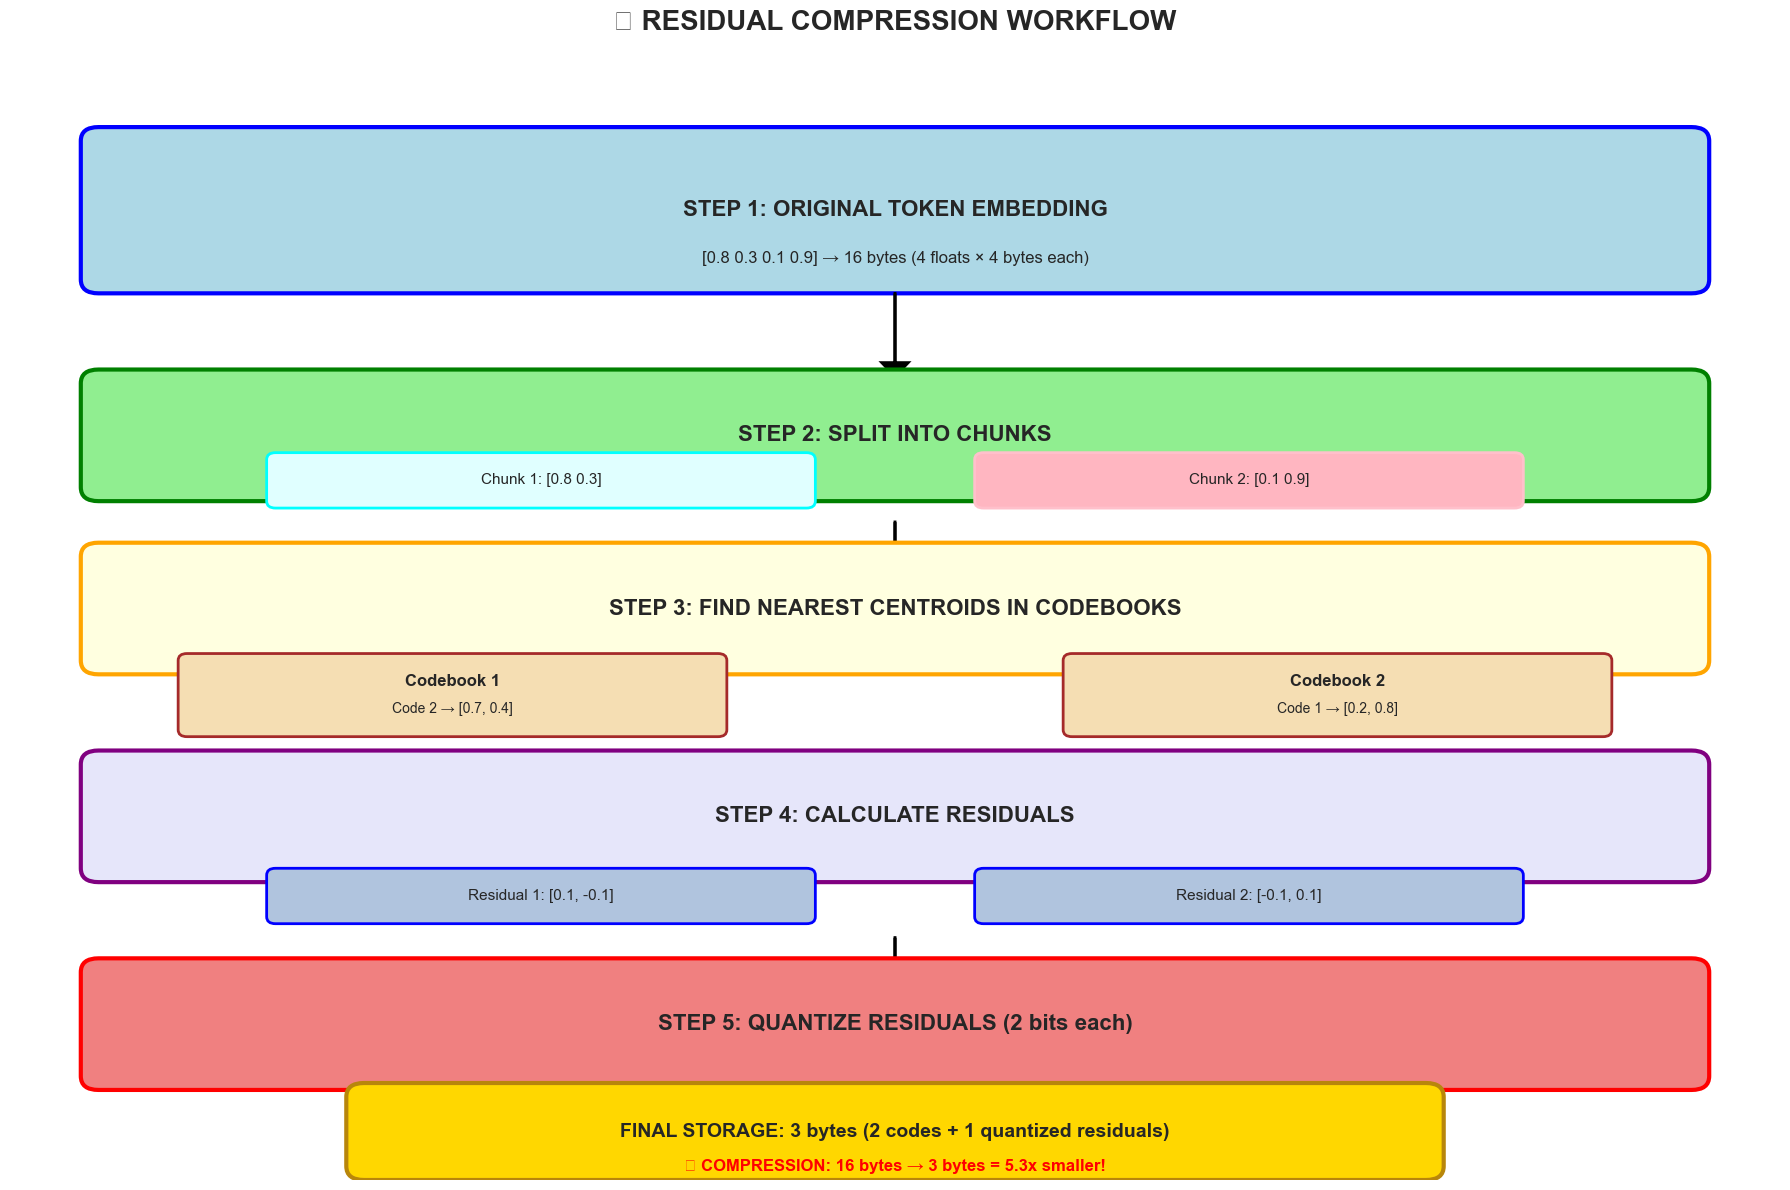

🔧 RESIDUAL COMPRESSION KEY INSIGHTS:
   1️⃣ Split vectors into smaller chunks (easier to compress)
   2️⃣ Many centroids = small residuals
   3️⃣ Small residuals = aggressive quantization possible
   4️⃣ Tiny reconstruction error for massive savings!
   🎯 Result: 5.3x compression with minimal quality loss


In [17]:
# Create visual workflow for residual compression
fig, ax = plt.subplots(1, 1, figsize=(18, 12))
ax.set_xlim(0, 20)
ax.set_ylim(0, 16)
ax.set_title("🔧 RESIDUAL COMPRESSION WORKFLOW", fontsize=20, fontweight='bold', pad=30)

# Original embedding
original_embedding = np.array([0.8, 0.3, 0.1, 0.9])

# Step 1: Original vector
step1_box = FancyBboxPatch((1, 13), 18, 2, boxstyle="round,pad=0.2", 
                           facecolor='lightblue', edgecolor='blue', linewidth=3)
ax.add_patch(step1_box)
ax.text(10, 14, "STEP 1: ORIGINAL TOKEN EMBEDDING", ha='center', va='center', 
        fontsize=16, fontweight='bold')
ax.text(10, 13.3, f"{original_embedding} → 16 bytes (4 floats × 4 bytes each)", 
        ha='center', va='center', fontsize=12)

# Arrow down
ax.arrow(10, 12.8, 0, -1, head_width=0.3, head_length=0.2, fc='black', ec='black', lw=2)

# Step 2: Split into chunks
step2_box = FancyBboxPatch((1, 10), 18, 1.5, boxstyle="round,pad=0.2", 
                           facecolor='lightgreen', edgecolor='green', linewidth=3)
ax.add_patch(step2_box)
ax.text(10, 10.75, "STEP 2: SPLIT INTO CHUNKS", ha='center', va='center', 
        fontsize=16, fontweight='bold')

# Show chunks visually
chunk1_box = FancyBboxPatch((3, 9.8), 6, 0.6, boxstyle="round,pad=0.1", 
                            facecolor='lightcyan', edgecolor='cyan', linewidth=2)
ax.add_patch(chunk1_box)
ax.text(6, 10.1, f"Chunk 1: {original_embedding[:2]}", ha='center', va='center', fontsize=11)

chunk2_box = FancyBboxPatch((11, 9.8), 6, 0.6, boxstyle="round,pad=0.1", 
                            facecolor='lightpink', edgecolor='pink', linewidth=2)
ax.add_patch(chunk2_box)
ax.text(14, 10.1, f"Chunk 2: {original_embedding[2:]}", ha='center', va='center', fontsize=11)

# Arrow down
ax.arrow(10, 9.5, 0, -0.8, head_width=0.3, head_length=0.2, fc='black', ec='black', lw=2)

# Step 3: Find nearest centroids
step3_box = FancyBboxPatch((1, 7.5), 18, 1.5, boxstyle="round,pad=0.2", 
                           facecolor='lightyellow', edgecolor='orange', linewidth=3)
ax.add_patch(step3_box)
ax.text(10, 8.25, "STEP 3: FIND NEAREST CENTROIDS IN CODEBOOKS", ha='center', va='center', 
        fontsize=16, fontweight='bold')

# Show codebooks
codebook1_box = FancyBboxPatch((2, 6.5), 6, 1, boxstyle="round,pad=0.1", 
                               facecolor='wheat', edgecolor='brown', linewidth=2)
ax.add_patch(codebook1_box)
ax.text(5, 7.2, "Codebook 1", ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(5, 6.8, "Code 2 → [0.7, 0.4]", ha='center', va='center', fontsize=10)

codebook2_box = FancyBboxPatch((12, 6.5), 6, 1, boxstyle="round,pad=0.1", 
                               facecolor='wheat', edgecolor='brown', linewidth=2)
ax.add_patch(codebook2_box)
ax.text(15, 7.2, "Codebook 2", ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(15, 6.8, "Code 1 → [0.2, 0.8]", ha='center', va='center', fontsize=10)

# Arrow down
ax.arrow(10, 6.2, 0, -0.8, head_width=0.3, head_length=0.2, fc='black', ec='black', lw=2)

# Step 4: Calculate residuals
step4_box = FancyBboxPatch((1, 4.5), 18, 1.5, boxstyle="round,pad=0.2", 
                           facecolor='lavender', edgecolor='purple', linewidth=3)
ax.add_patch(step4_box)
ax.text(10, 5.25, "STEP 4: CALCULATE RESIDUALS", ha='center', va='center', 
        fontsize=16, fontweight='bold')

residual1_box = FancyBboxPatch((3, 3.8), 6, 0.6, boxstyle="round,pad=0.1", 
                               facecolor='lightsteelblue', edgecolor='blue', linewidth=2)
ax.add_patch(residual1_box)
ax.text(6, 4.1, "Residual 1: [0.1, -0.1]", ha='center', va='center', fontsize=11)

residual2_box = FancyBboxPatch((11, 3.8), 6, 0.6, boxstyle="round,pad=0.1", 
                               facecolor='lightsteelblue', edgecolor='blue', linewidth=2)
ax.add_patch(residual2_box)
ax.text(14, 4.1, "Residual 2: [-0.1, 0.1]", ha='center', va='center', fontsize=11)

# Arrow down
ax.arrow(10, 3.5, 0, -0.8, head_width=0.3, head_length=0.2, fc='black', ec='black', lw=2)

# Step 5: Quantize residuals
step5_box = FancyBboxPatch((1, 1.5), 18, 1.5, boxstyle="round,pad=0.2", 
                           facecolor='lightcoral', edgecolor='red', linewidth=3)
ax.add_patch(step5_box)
ax.text(10, 2.25, "STEP 5: QUANTIZE RESIDUALS (2 bits each)", ha='center', va='center', 
        fontsize=16, fontweight='bold')

# Final storage breakdown
final_box = FancyBboxPatch((4, 0.2), 12, 1, boxstyle="round,pad=0.2", 
                           facecolor='gold', edgecolor='darkgoldenrod', linewidth=3)
ax.add_patch(final_box)
ax.text(10, 0.7, "FINAL STORAGE: 3 bytes (2 codes + 1 quantized residuals)", 
        ha='center', va='center', fontsize=14, fontweight='bold')

# Add compression ratio
compression_ratio = 16/3
ax.text(10, 0.2, f"🎯 COMPRESSION: 16 bytes → 3 bytes = {compression_ratio:.1f}x smaller!", 
        ha='center', va='center', fontsize=12, fontweight='bold', color='red')

ax.axis('off')
plt.tight_layout()
plt.show()

print("🔧 RESIDUAL COMPRESSION KEY INSIGHTS:")
print("   1️⃣ Split vectors into smaller chunks (easier to compress)")
print("   2️⃣ Many centroids = small residuals")  
print("   3️⃣ Small residuals = aggressive quantization possible")
print("   4️⃣ Tiny reconstruction error for massive savings!")
print(f"   🎯 Result: {compression_ratio:.1f}x compression with minimal quality loss")

In [18]:
# Reconstruction process
print("🔄 RECONSTRUCTION PROCESS")
print()

print(f"Step 1 - Look up codes in codebooks:")
print(f"  Code {nearest_code1} → {nearest_centroid1}")
print(f"  Code {nearest_code2} → {nearest_centroid2}")
print()

print(f"Step 2 - Add quantized residuals:")
reconstructed_chunk1 = nearest_centroid1 + quantized_residual1
reconstructed_chunk2 = nearest_centroid2 + quantized_residual2

print(f"  Chunk 1: {nearest_centroid1} + {quantized_residual1} = {reconstructed_chunk1}")
print(f"  Chunk 2: {nearest_centroid2} + {quantized_residual2} = {reconstructed_chunk2}")
print()

reconstructed_embedding = np.concatenate([reconstructed_chunk1, reconstructed_chunk2])
print(f"Step 3 - Combine chunks:")
print(f"  Original:      {original_embedding}")
print(f"  Reconstructed: {reconstructed_embedding}")

error = np.linalg.norm(original_embedding - reconstructed_embedding)
print(f"  Reconstruction error: {error:.4f}")
print(f"  ✅ Very small error for massive compression!")

🔄 RECONSTRUCTION PROCESS

Step 1 - Look up codes in codebooks:
  Code 2 → [0.7 0.4]
  Code 1 → [0.2 0.8]

Step 2 - Add quantized residuals:
  Chunk 1: [0.7 0.4] + [ 0.15 -0.15] = [0.85 0.25]
  Chunk 2: [0.2 0.8] + [-0.15  0.05] = [0.05 0.85]

Step 3 - Combine chunks:
  Original:      [0.8 0.3 0.1 0.9]
  Reconstructed: [0.85 0.25 0.05 0.85]
  Reconstruction error: 0.1000
  ✅ Very small error for massive compression!


### Why Residual Compression Works

1. **Many clusters (256+)** → Small residuals
2. **Small residuals** → Can quantize aggressively 
3. **Accept tiny errors** → Massive storage savings
4. **Result: 6-10x compression** with minimal quality loss!

### Innovation 2: Denoised Supervision

**The Problem:** Auto-generated training labels were garbage  
**The Solution:** Use a smarter "teacher" model to fix the labels

/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/1753048578.py:89: UserWarning: Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/1753048578.py:89: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/1753048578.py:89: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/1753048578.py:89: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
/Users/luvsuneja/Documents/repos/advanced-rag-experimentation/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/luvsuneja/Documents/repos/advanced

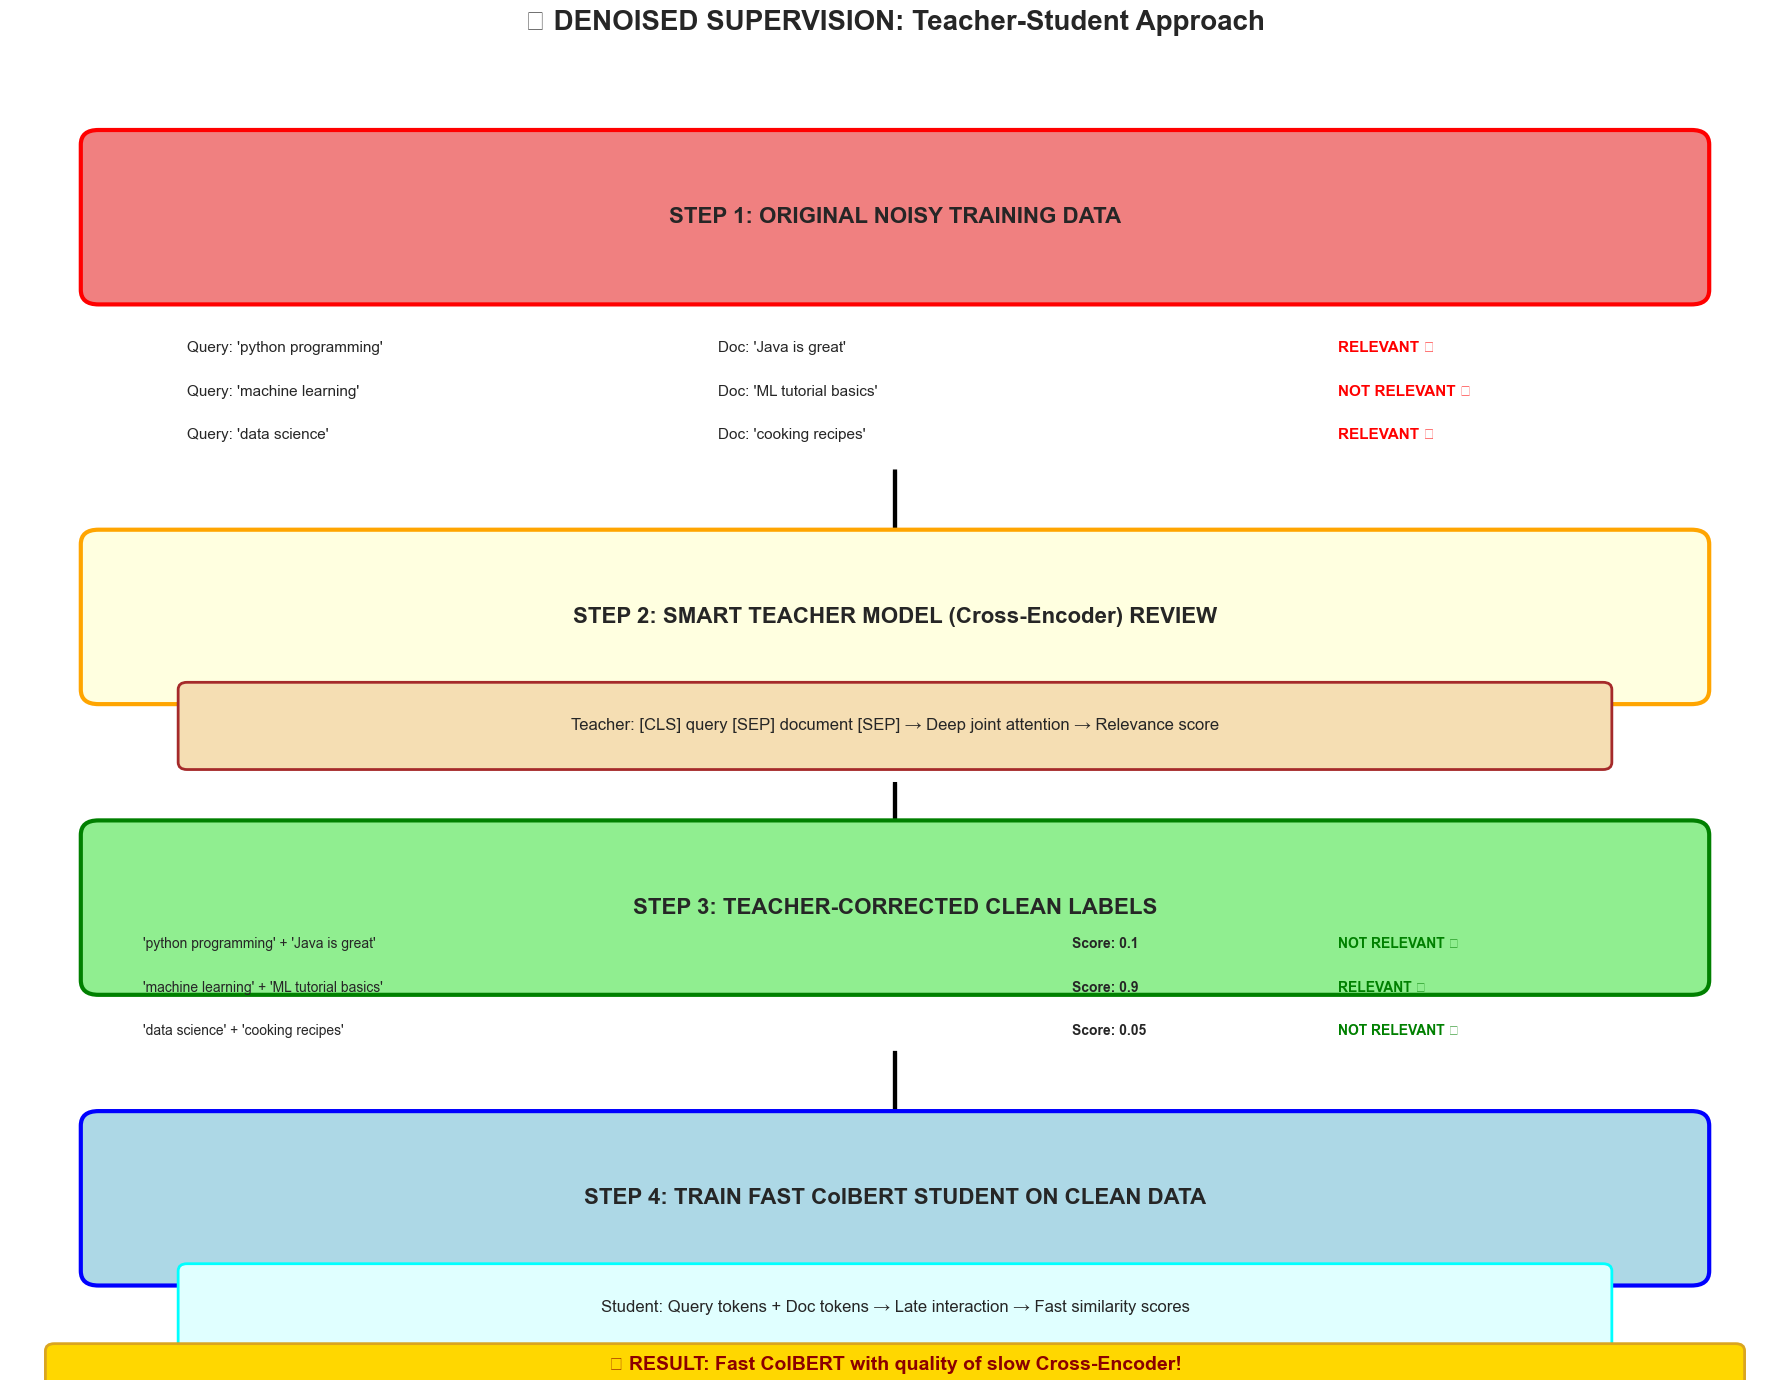

/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/1753048578.py:162: UserWarning: Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/1753048578.py:162: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/1753048578.py:162: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/1753048578.py:162: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.tight_layout()
/Users/luvsuneja/Documents/repos/advanced-rag-experimentation/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


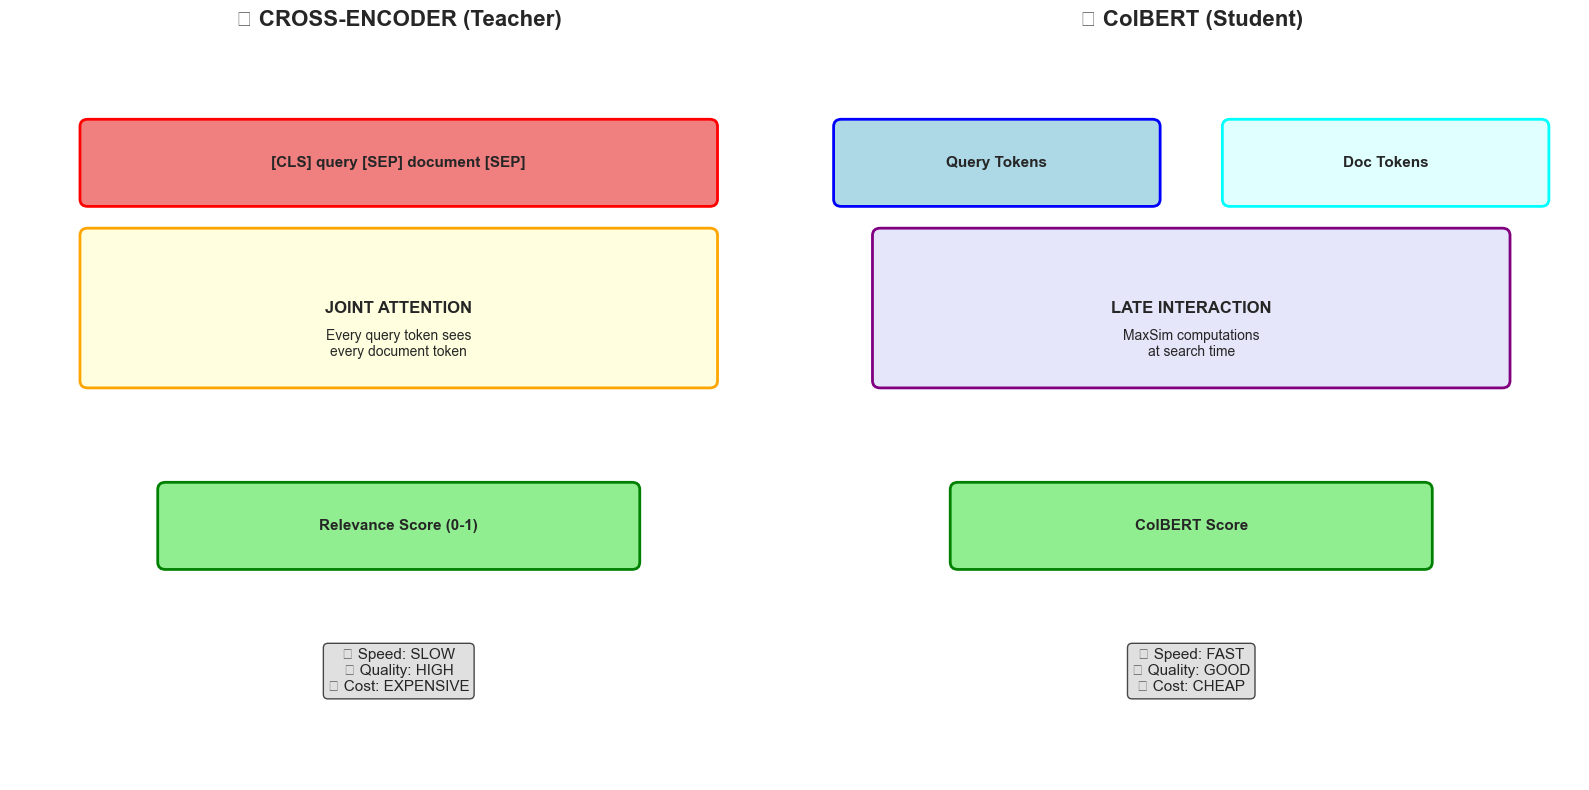

🎓 TEACHER-STUDENT KEY INSIGHTS:
   🔴 Problem: Auto-generated training data is 30% wrong
   🟡 Solution: Use smart cross-encoder to clean labels (offline)
   🟢 Benefit: ColBERT learns from much higher quality data
   🎯 Result: +6.5% better performance than original ColBERT v2!
   💡 Strategy: Get best of both worlds - quality + speed


In [19]:
# Create teacher-student supervision visualization
fig, ax = plt.subplots(1, 1, figsize=(18, 14))
ax.set_xlim(0, 20)
ax.set_ylim(0, 18)
ax.set_title("🎓 DENOISED SUPERVISION: Teacher-Student Approach", fontsize=20, fontweight='bold', pad=30)

# Step 1: Noisy training data
noisy_box = FancyBboxPatch((1, 15), 18, 2, boxstyle="round,pad=0.2", 
                           facecolor='lightcoral', edgecolor='red', linewidth=3)
ax.add_patch(noisy_box)
ax.text(10, 16, "STEP 1: ORIGINAL NOISY TRAINING DATA", ha='center', va='center', 
        fontsize=16, fontweight='bold')

# Show example noisy labels
examples_y = [14.2, 13.6, 13.0]
examples = [
    ("'python programming'", "'Java is great'", "RELEVANT ❌"),
    ("'machine learning'", "'ML tutorial basics'", "NOT RELEVANT ❌"),
    ("'data science'", "'cooking recipes'", "RELEVANT ❌")
]

for i, (query, doc, label) in enumerate(examples):
    ax.text(2, examples_y[i], f"Query: {query}", ha='left', va='center', fontsize=11)
    ax.text(8, examples_y[i], f"Doc: {doc}", ha='left', va='center', fontsize=11)
    ax.text(15, examples_y[i], label, ha='left', va='center', fontsize=11, fontweight='bold', color='red')

# Arrow down
ax.arrow(10, 12.5, 0, -1, head_width=0.4, head_length=0.3, fc='black', ec='black', lw=3)

# Step 2: Teacher model review
teacher_box = FancyBboxPatch((1, 9.5), 18, 2, boxstyle="round,pad=0.2", 
                             facecolor='lightyellow', edgecolor='orange', linewidth=3)
ax.add_patch(teacher_box)
ax.text(10, 10.5, "STEP 2: SMART TEACHER MODEL (Cross-Encoder) REVIEW", ha='center', va='center', 
        fontsize=16, fontweight='bold')

# Show teacher architecture
teacher_arch_box = FancyBboxPatch((2, 8.5), 16, 1, boxstyle="round,pad=0.1", 
                                  facecolor='wheat', edgecolor='brown', linewidth=2)
ax.add_patch(teacher_arch_box)
ax.text(10, 9, "Teacher: [CLS] query [SEP] document [SEP] → Deep joint attention → Relevance score", 
        ha='center', va='center', fontsize=12)

# Arrow down
ax.arrow(10, 8.2, 0, -1, head_width=0.4, head_length=0.3, fc='black', ec='black', lw=3)

# Step 3: Corrected labels
corrected_box = FancyBboxPatch((1, 5.5), 18, 2, boxstyle="round,pad=0.2", 
                               facecolor='lightgreen', edgecolor='green', linewidth=3)
ax.add_patch(corrected_box)
ax.text(10, 6.5, "STEP 3: TEACHER-CORRECTED CLEAN LABELS", ha='center', va='center', 
        fontsize=16, fontweight='bold')

# Show corrected examples with scores
corrected_y = [6.0, 5.4, 4.8]
teacher_scores = [0.1, 0.9, 0.05]
corrected_labels = ["NOT RELEVANT ✅", "RELEVANT ✅", "NOT RELEVANT ✅"]

for i, ((query, doc, _), score, new_label) in enumerate(zip(examples, teacher_scores, corrected_labels)):
    ax.text(1.5, corrected_y[i], f"{query} + {doc}", ha='left', va='center', fontsize=10)
    ax.text(12, corrected_y[i], f"Score: {score}", ha='left', va='center', fontsize=10, fontweight='bold')
    ax.text(15, corrected_y[i], new_label, ha='left', va='center', fontsize=10, fontweight='bold', color='green')

# Arrow down
ax.arrow(10, 4.5, 0, -1, head_width=0.4, head_length=0.3, fc='black', ec='black', lw=3)

# Step 4: Student training
student_box = FancyBboxPatch((1, 1.5), 18, 2, boxstyle="round,pad=0.2", 
                             facecolor='lightblue', edgecolor='blue', linewidth=3)
ax.add_patch(student_box)
ax.text(10, 2.5, "STEP 4: TRAIN FAST ColBERT STUDENT ON CLEAN DATA", ha='center', va='center', 
        fontsize=16, fontweight='bold')

# Show student architecture
student_arch_box = FancyBboxPatch((2, 0.5), 16, 1, boxstyle="round,pad=0.1", 
                                  facecolor='lightcyan', edgecolor='cyan', linewidth=2)
ax.add_patch(student_arch_box)
ax.text(10, 1, "Student: Query tokens + Doc tokens → Late interaction → Fast similarity scores", 
        ha='center', va='center', fontsize=12)

# Add benefits annotations
benefits_box = FancyBboxPatch((0.5, 0), 19, 0.4, boxstyle="round,pad=0.1", 
                              facecolor='gold', edgecolor='goldenrod', linewidth=2)
ax.add_patch(benefits_box)
ax.text(10, 0.2, "🎯 RESULT: Fast ColBERT with quality of slow Cross-Encoder!", 
        ha='center', va='center', fontsize=14, fontweight='bold', color='darkred')

ax.axis('off')
plt.tight_layout()
plt.show()

# Create architecture comparison
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Cross-Encoder (Teacher)
ax1.set_title("🎓 CROSS-ENCODER (Teacher)", fontsize=16, fontweight='bold', pad=20)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)

# Input representation
input_box = FancyBboxPatch((1, 8), 8, 1, boxstyle="round,pad=0.1", 
                           facecolor='lightcoral', edgecolor='red', linewidth=2)
ax1.add_patch(input_box)
ax1.text(5, 8.5, "[CLS] query [SEP] document [SEP]", ha='center', va='center', fontsize=11, fontweight='bold')

# Joint processing
process_box = FancyBboxPatch((1, 5.5), 8, 2, boxstyle="round,pad=0.1", 
                             facecolor='lightyellow', edgecolor='orange', linewidth=2)
ax1.add_patch(process_box)
ax1.text(5, 6.5, "JOINT ATTENTION", ha='center', va='center', fontsize=12, fontweight='bold')
ax1.text(5, 6, "Every query token sees\nevery document token", ha='center', va='center', fontsize=10)

# Output
output_box = FancyBboxPatch((2, 3), 6, 1, boxstyle="round,pad=0.1", 
                            facecolor='lightgreen', edgecolor='green', linewidth=2)
ax1.add_patch(output_box)
ax1.text(5, 3.5, "Relevance Score (0-1)", ha='center', va='center', fontsize=11, fontweight='bold')

# Properties
ax1.text(5, 1.5, "⚡ Speed: SLOW\n🎯 Quality: HIGH\n💰 Cost: EXPENSIVE", 
         ha='center', va='center', fontsize=11, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray', alpha=0.7))

ax1.axis('off')

# ColBERT (Student)
ax2.set_title("🎓 ColBERT (Student)", fontsize=16, fontweight='bold', pad=20)
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)

# Separate processing
query_box = FancyBboxPatch((0.5, 8), 4, 1, boxstyle="round,pad=0.1", 
                           facecolor='lightblue', edgecolor='blue', linewidth=2)
ax2.add_patch(query_box)
ax2.text(2.5, 8.5, "Query Tokens", ha='center', va='center', fontsize=11, fontweight='bold')

doc_box = FancyBboxPatch((5.5, 8), 4, 1, boxstyle="round,pad=0.1", 
                         facecolor='lightcyan', edgecolor='cyan', linewidth=2)
ax2.add_patch(doc_box)
ax2.text(7.5, 8.5, "Doc Tokens", ha='center', va='center', fontsize=11, fontweight='bold')

# Late interaction
interaction_box = FancyBboxPatch((1, 5.5), 8, 2, boxstyle="round,pad=0.1", 
                                 facecolor='lavender', edgecolor='purple', linewidth=2)
ax2.add_patch(interaction_box)
ax2.text(5, 6.5, "LATE INTERACTION", ha='center', va='center', fontsize=12, fontweight='bold')
ax2.text(5, 6, "MaxSim computations\nat search time", ha='center', va='center', fontsize=10)

# Output
output_box2 = FancyBboxPatch((2, 3), 6, 1, boxstyle="round,pad=0.1", 
                             facecolor='lightgreen', edgecolor='green', linewidth=2)
ax2.add_patch(output_box2)
ax2.text(5, 3.5, "ColBERT Score", ha='center', va='center', fontsize=11, fontweight='bold')

# Properties
ax2.text(5, 1.5, "⚡ Speed: FAST\n🎯 Quality: GOOD\n💰 Cost: CHEAP", 
         ha='center', va='center', fontsize=11, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray', alpha=0.7))

ax2.axis('off')

plt.tight_layout()
plt.show()

print("🎓 TEACHER-STUDENT KEY INSIGHTS:")
print("   🔴 Problem: Auto-generated training data is 30% wrong")
print("   🟡 Solution: Use smart cross-encoder to clean labels (offline)")
print("   🟢 Benefit: ColBERT learns from much higher quality data") 
print("   🎯 Result: +6.5% better performance than original ColBERT v2!")
print("   💡 Strategy: Get best of both worlds - quality + speed")

### Cross-Encoder vs ColBERT Architecture

In [20]:
print("🏗️ ARCHITECTURE COMPARISON")
print()

print("🎓 Cross-Encoder (Teacher):")
print("  Input: [CLS] query [SEP] document [SEP]")
print("  Processing: Joint attention - query and doc tokens interact")
print("  Output: Single relevance score (0-1)")
print("  Speed: SLOW (must process each query-doc pair separately)")
print("  Quality: HIGH (deep understanding of relationships)")
print()

print("🎓 ColBERT (Student):")
print("  Input: Query and document processed separately")
print("  Processing: Late interaction - tokens interact only at the end")
print("  Output: Token-level similarities → MaxSim scores")
print("  Speed: FAST (can pre-compute document embeddings)")
print("  Quality: GOOD (but not as deep as cross-encoder)")
print()

print("💡 Strategy:")
print("  1. Use slow, smart cross-encoder to clean training data (offline)")
print("  2. Train fast ColBERT on the cleaned data")
print("  3. Deploy fast ColBERT for real-time search")
print("  4. Get best of both worlds: speed + quality!")

🏗️ ARCHITECTURE COMPARISON

🎓 Cross-Encoder (Teacher):
  Input: [CLS] query [SEP] document [SEP]
  Processing: Joint attention - query and doc tokens interact
  Output: Single relevance score (0-1)
  Speed: SLOW (must process each query-doc pair separately)
  Quality: HIGH (deep understanding of relationships)

🎓 ColBERT (Student):
  Input: Query and document processed separately
  Processing: Late interaction - tokens interact only at the end
  Output: Token-level similarities → MaxSim scores
  Speed: FAST (can pre-compute document embeddings)
  Quality: GOOD (but not as deep as cross-encoder)

💡 Strategy:
  1. Use slow, smart cross-encoder to clean training data (offline)
  2. Train fast ColBERT on the cleaned data
  3. Deploy fast ColBERT for real-time search
  4. Get best of both worlds: speed + quality!


### Innovation 3: PLAID Search Engine

**The Challenge:** Late interaction = millions of similarity computations per query  
**The Solution:** Multi-stage filtering (coarse → approximate → exact)

/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/2376962699.py:121: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/2376962699.py:121: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/2376962699.py:121: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/2376962699.py:121: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/2376962699.py:121: UserWarning: Glyph 128561 (\N{FACE SCREAMING IN FEAR}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/2376962699.py:121: UserW

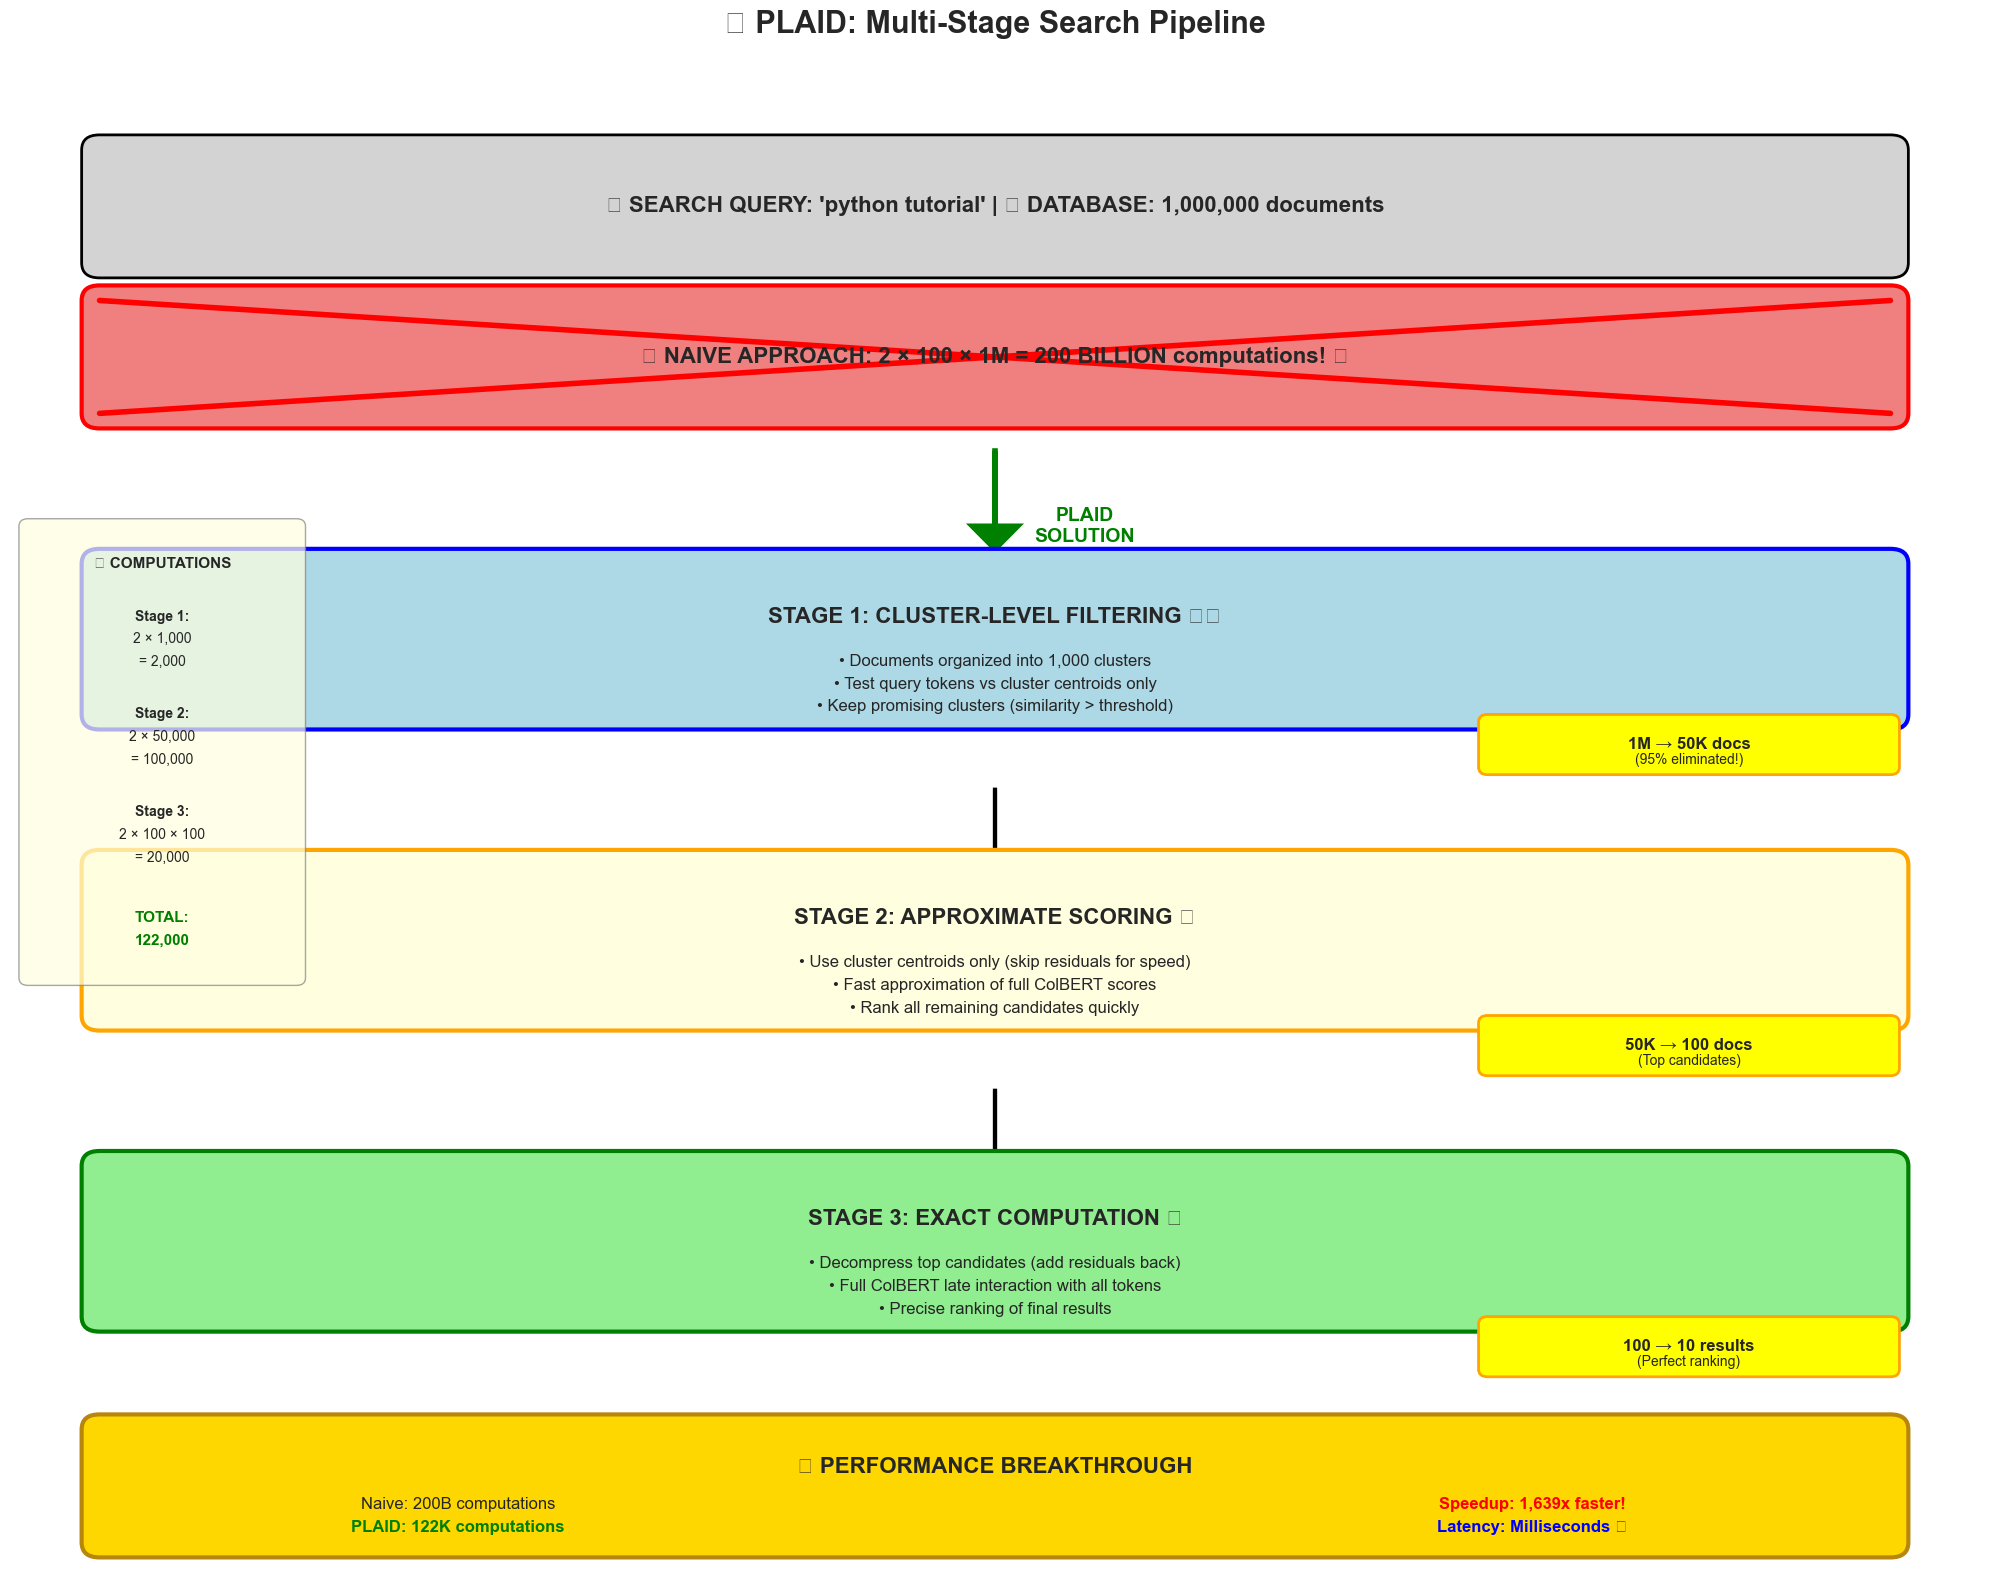

/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/2376962699.py:160: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()


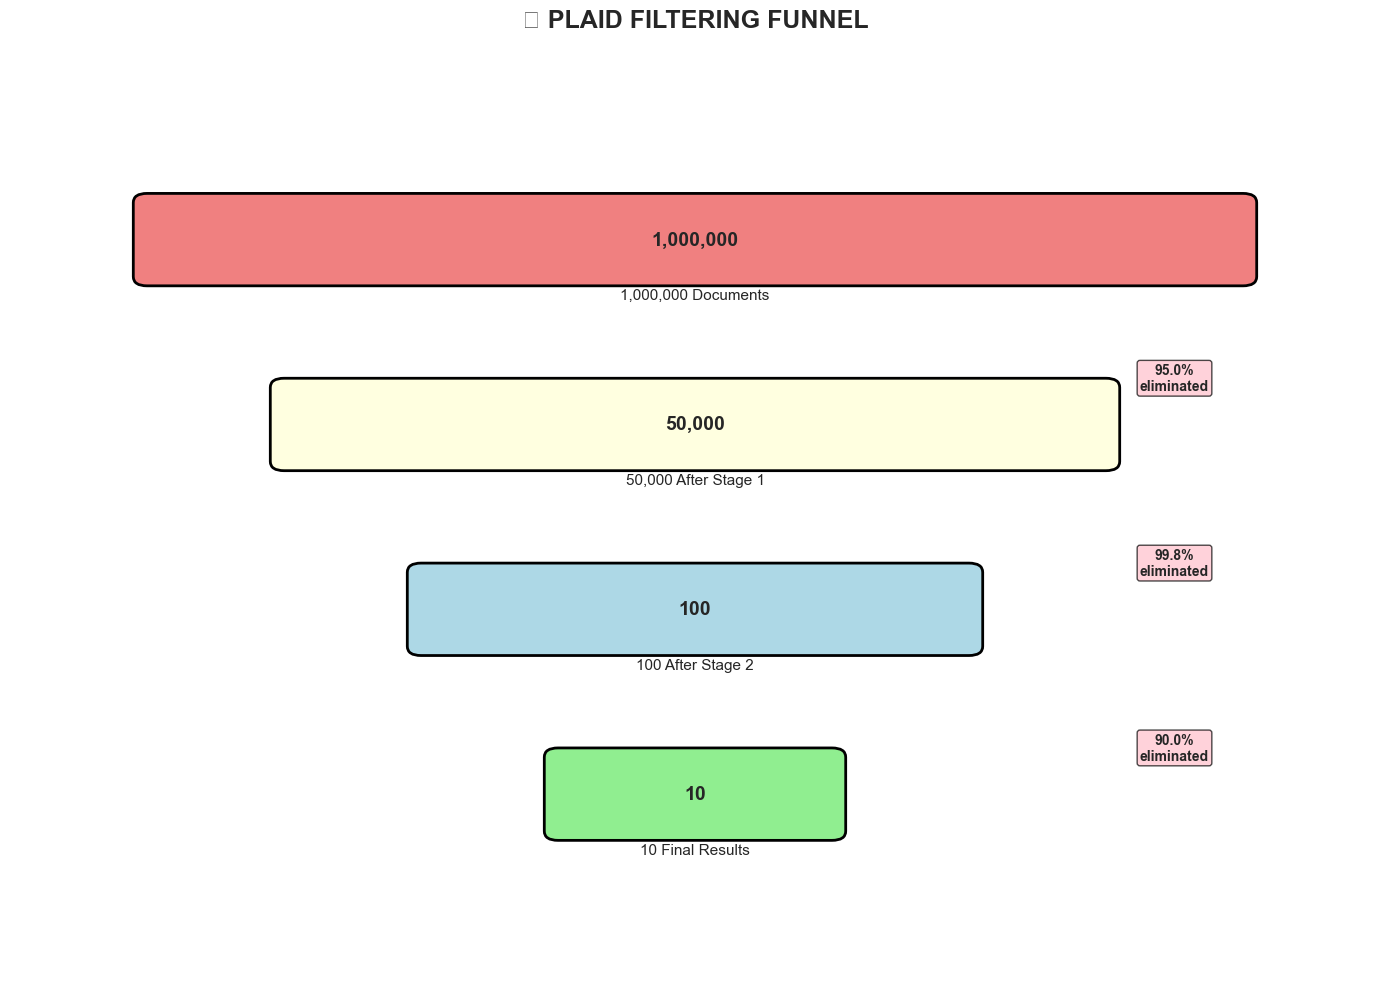

⚡ PLAID KEY INSIGHTS:
   🎯 Multi-stage filtering: Coarse → Approximate → Exact
   📊 Massive elimination: 1M → 50K → 100 → 10 documents
   🚀 Speed: 1,639x faster than naive approach
   💡 Smart trade-off: Use fast approximations to find exact candidates
   ⚡ Result: Millisecond search latency at web scale!
   🏆 Best of all worlds: Quality + Speed + Scalability


In [21]:
# Create comprehensive PLAID pipeline visualization
fig, ax = plt.subplots(1, 1, figsize=(20, 16))
ax.set_xlim(0, 22)
ax.set_ylim(0, 20)
ax.set_title("⚡ PLAID: Multi-Stage Search Pipeline", fontsize=22, fontweight='bold', pad=30)

# Initial setup
setup_box = FancyBboxPatch((1, 17.5), 20, 1.5, boxstyle="round,pad=0.2", 
                           facecolor='lightgray', edgecolor='black', linewidth=2)
ax.add_patch(setup_box)
ax.text(11, 18.25, "🔍 SEARCH QUERY: 'python tutorial' | 📚 DATABASE: 1,000,000 documents", 
        ha='center', va='center', fontsize=16, fontweight='bold')

# Naive approach (crossed out)
naive_box = FancyBboxPatch((1, 15.5), 20, 1.5, boxstyle="round,pad=0.2", 
                           facecolor='lightcoral', edgecolor='red', linewidth=3)
ax.add_patch(naive_box)
ax.text(11, 16.25, "❌ NAIVE APPROACH: 2 × 100 × 1M = 200 BILLION computations! 😱", 
        ha='center', va='center', fontsize=16, fontweight='bold')
# Add crossed-out effect
ax.plot([1, 21], [15.5, 17], 'red', linewidth=4)
ax.plot([1, 21], [17, 15.5], 'red', linewidth=4)

# Arrow down to PLAID
ax.arrow(11, 15, 0, -1, head_width=0.5, head_length=0.3, fc='green', ec='green', lw=4)
ax.text(12, 14, "PLAID\nSOLUTION", ha='center', va='center', fontsize=14, fontweight='bold', color='green')

# Stage 1: Cluster filtering
stage1_box = FancyBboxPatch((1, 11.5), 20, 2, boxstyle="round,pad=0.2", 
                            facecolor='lightblue', edgecolor='blue', linewidth=3)
ax.add_patch(stage1_box)
ax.text(11, 12.8, "STAGE 1: CLUSTER-LEVEL FILTERING 🗂️", ha='center', va='center', 
        fontsize=16, fontweight='bold')
ax.text(11, 12.2, "• Documents organized into 1,000 clusters", ha='center', va='center', fontsize=12)
ax.text(11, 11.9, "• Test query tokens vs cluster centroids only", ha='center', va='center', fontsize=12)
ax.text(11, 11.6, "• Keep promising clusters (similarity > threshold)", ha='center', va='center', fontsize=12)

# Results box for stage 1
result1_box = FancyBboxPatch((16.5, 10.8), 4.5, 0.6, boxstyle="round,pad=0.1", 
                             facecolor='yellow', edgecolor='orange', linewidth=2)
ax.add_patch(result1_box)
ax.text(18.75, 11.1, "1M → 50K docs", ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(18.75, 10.9, "(95% eliminated!)", ha='center', va='center', fontsize=10)

# Arrow down
ax.arrow(11, 10.5, 0, -1, head_width=0.4, head_length=0.2, fc='black', ec='black', lw=3)

# Stage 2: Approximate scoring
stage2_box = FancyBboxPatch((1, 7.5), 20, 2, boxstyle="round,pad=0.2", 
                            facecolor='lightyellow', edgecolor='orange', linewidth=3)
ax.add_patch(stage2_box)
ax.text(11, 8.8, "STAGE 2: APPROXIMATE SCORING 📊", ha='center', va='center', 
        fontsize=16, fontweight='bold')
ax.text(11, 8.2, "• Use cluster centroids only (skip residuals for speed)", ha='center', va='center', fontsize=12)
ax.text(11, 7.9, "• Fast approximation of full ColBERT scores", ha='center', va='center', fontsize=12)
ax.text(11, 7.6, "• Rank all remaining candidates quickly", ha='center', va='center', fontsize=12)

# Results box for stage 2
result2_box = FancyBboxPatch((16.5, 6.8), 4.5, 0.6, boxstyle="round,pad=0.1", 
                             facecolor='yellow', edgecolor='orange', linewidth=2)
ax.add_patch(result2_box)
ax.text(18.75, 7.1, "50K → 100 docs", ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(18.75, 6.9, "(Top candidates)", ha='center', va='center', fontsize=10)

# Arrow down
ax.arrow(11, 6.5, 0, -1, head_width=0.4, head_length=0.2, fc='black', ec='black', lw=3)

# Stage 3: Exact computation
stage3_box = FancyBboxPatch((1, 3.5), 20, 2, boxstyle="round,pad=0.2", 
                            facecolor='lightgreen', edgecolor='green', linewidth=3)
ax.add_patch(stage3_box)
ax.text(11, 4.8, "STAGE 3: EXACT COMPUTATION 🎯", ha='center', va='center', 
        fontsize=16, fontweight='bold')
ax.text(11, 4.2, "• Decompress top candidates (add residuals back)", ha='center', va='center', fontsize=12)
ax.text(11, 3.9, "• Full ColBERT late interaction with all tokens", ha='center', va='center', fontsize=12)
ax.text(11, 3.6, "• Precise ranking of final results", ha='center', va='center', fontsize=12)

# Results box for stage 3
result3_box = FancyBboxPatch((16.5, 2.8), 4.5, 0.6, boxstyle="round,pad=0.1", 
                             facecolor='yellow', edgecolor='orange', linewidth=2)
ax.add_patch(result3_box)
ax.text(18.75, 3.1, "100 → 10 results", ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(18.75, 2.9, "(Perfect ranking)", ha='center', va='center', fontsize=10)

# Final performance box
performance_box = FancyBboxPatch((1, 0.5), 20, 1.5, boxstyle="round,pad=0.2", 
                                 facecolor='gold', edgecolor='darkgoldenrod', linewidth=3)
ax.add_patch(performance_box)
ax.text(11, 1.5, "🚀 PERFORMANCE BREAKTHROUGH", ha='center', va='center', 
        fontsize=16, fontweight='bold')

# Performance metrics side by side
ax.text(5, 1, "Naive: 200B computations", ha='center', va='center', fontsize=12)
ax.text(5, 0.7, "PLAID: 122K computations", ha='center', va='center', fontsize=12, fontweight='bold', color='green')

ax.text(17, 1, "Speedup: 1,639x faster!", ha='center', va='center', fontsize=12, fontweight='bold', color='red')
ax.text(17, 0.7, "Latency: Milliseconds ⚡", ha='center', va='center', fontsize=12, fontweight='bold', color='blue')

# Add computation breakdown on the side
comp_box = FancyBboxPatch((0.2, 8), 3, 6, boxstyle="round,pad=0.1", 
                          facecolor='lightyellow', edgecolor='gray', linewidth=1, alpha=0.7)
ax.add_patch(comp_box)
ax.text(1.7, 13.5, "💻 COMPUTATIONS", ha='center', va='center', fontsize=11, fontweight='bold')

ax.text(1.7, 12.8, "Stage 1:", ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(1.7, 12.5, "2 × 1,000", ha='center', va='center', fontsize=10)
ax.text(1.7, 12.2, "= 2,000", ha='center', va='center', fontsize=10)

ax.text(1.7, 11.5, "Stage 2:", ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(1.7, 11.2, "2 × 50,000", ha='center', va='center', fontsize=10)
ax.text(1.7, 10.9, "= 100,000", ha='center', va='center', fontsize=10)

ax.text(1.7, 10.2, "Stage 3:", ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(1.7, 9.9, "2 × 100 × 100", ha='center', va='center', fontsize=10)
ax.text(1.7, 9.6, "= 20,000", ha='center', va='center', fontsize=10)

ax.text(1.7, 8.8, "TOTAL:", ha='center', va='center', fontsize=11, fontweight='bold', color='green')
ax.text(1.7, 8.5, "122,000", ha='center', va='center', fontsize=11, fontweight='bold', color='green')

ax.axis('off')
plt.tight_layout()
plt.show()

# Create a funnel visualization
fig2, ax2 = plt.subplots(1, 1, figsize=(14, 10))
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.set_title("📊 PLAID FILTERING FUNNEL", fontsize=18, fontweight='bold', pad=20)

# Create funnel stages
funnel_data = [
    (1000000, "1,000,000 Documents", 'lightcoral'),
    (50000, "50,000 After Stage 1", 'lightyellow'),
    (100, "100 After Stage 2", 'lightblue'),
    (10, "10 Final Results", 'lightgreen')
]

y_positions = [8, 6, 4, 2]
box_widths = [8, 6, 4, 2]

for i, ((count, label, color), y_pos, width) in enumerate(zip(funnel_data, y_positions, box_widths)):
    x_pos = 5 - width/2  # Center the box
    
    box = FancyBboxPatch((x_pos, y_pos-0.4), width, 0.8, boxstyle="round,pad=0.1", 
                         facecolor=color, edgecolor='black', linewidth=2)
    ax2.add_patch(box)
    
    ax2.text(5, y_pos, f"{count:,}", ha='center', va='center', fontsize=14, fontweight='bold')
    ax2.text(5, y_pos-0.6, label, ha='center', va='center', fontsize=11)
    
    # Add elimination percentages
    if i > 0:
        prev_count = funnel_data[i-1][0]
        elimination = ((prev_count - count) / prev_count) * 100
        ax2.text(8.5, y_pos + 0.5, f"{elimination:.1f}%\neliminated", 
                ha='center', va='center', fontsize=10, fontweight='bold', 
                bbox=dict(boxstyle="round,pad=0.2", facecolor='pink', alpha=0.7))

ax2.axis('off')
plt.tight_layout()
plt.show()

print("⚡ PLAID KEY INSIGHTS:")
print("   🎯 Multi-stage filtering: Coarse → Approximate → Exact")
print("   📊 Massive elimination: 1M → 50K → 100 → 10 documents")
print("   🚀 Speed: 1,639x faster than naive approach")
print("   💡 Smart trade-off: Use fast approximations to find exact candidates")
print("   ⚡ Result: Millisecond search latency at web scale!")
print("   🏆 Best of all worlds: Quality + Speed + Scalability")

### Innovation 4: Index Organization

**Efficient storage and retrieval of compressed embeddings**

In [22]:
print("🗂️ INDEX ORGANIZATION")
print()

print("📁 File Structure:")
print("  embeddings.bin     ← Compressed token embeddings")
print("  cluster_index.idx  ← Inverted index: cluster → documents")
print("  metadata.json      ← Document lengths, offsets, etc.")
print()

print("📊 Inverted Index Example:")
print()

# Example documents and their cluster assignments
documents = {
    1: {"text": "python tutorial basics", "clusters": [5, 8, 2]},
    2: {"text": "java programming guide", "clusters": [3, 5, 8]},
    3: {"text": "machine learning python", "clusters": [1, 2, 5]}
}

print("Documents and their token clusters:")
for doc_id, info in documents.items():
    print(f"  Doc {doc_id}: '{info['text']}' → Clusters {info['clusters']}")
print()

# Build inverted index
inverted_index = {}
for doc_id, info in documents.items():
    for cluster in info['clusters']:
        if cluster not in inverted_index:
            inverted_index[cluster] = []
        inverted_index[cluster].append(doc_id)

print("Inverted Index (cluster → documents):")
for cluster in sorted(inverted_index.keys()):
    docs = inverted_index[cluster]
    print(f"  Cluster {cluster}: Documents {docs}")
print()

print("🔍 Search Example:")
query_clusters = [5, 8]  # "python tutorial" maps to these clusters
print(f"Query clusters: {query_clusters}")

candidate_docs = set()
for cluster in query_clusters:
    if cluster in inverted_index:
        candidate_docs.update(inverted_index[cluster])
        print(f"  Cluster {cluster} → Documents {inverted_index[cluster]}")

print(f"  Combined candidates: {sorted(candidate_docs)}")
print(f"  🎯 Instant lookup! No need to scan all documents.")

🗂️ INDEX ORGANIZATION

📁 File Structure:
  embeddings.bin     ← Compressed token embeddings
  cluster_index.idx  ← Inverted index: cluster → documents
  metadata.json      ← Document lengths, offsets, etc.

📊 Inverted Index Example:

Documents and their token clusters:
  Doc 1: 'python tutorial basics' → Clusters [5, 8, 2]
  Doc 2: 'java programming guide' → Clusters [3, 5, 8]
  Doc 3: 'machine learning python' → Clusters [1, 2, 5]

Inverted Index (cluster → documents):
  Cluster 1: Documents [3]
  Cluster 2: Documents [1, 3]
  Cluster 3: Documents [2]
  Cluster 5: Documents [1, 2, 3]
  Cluster 8: Documents [1, 2]

🔍 Search Example:
Query clusters: [5, 8]
  Cluster 5 → Documents [1, 2, 3]
  Cluster 8 → Documents [1, 2]
  Combined candidates: [1, 2, 3]
  🎯 Instant lookup! No need to scan all documents.


---

## 4. ColBERT v2 Results

### Performance Improvements

/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/4245140697.py:107: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/4245140697.py:107: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/4245140697.py:107: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/4245140697.py:107: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/4245140697.py:107: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/4245140697.py:107: UserWarning: Glyph 128176 (\

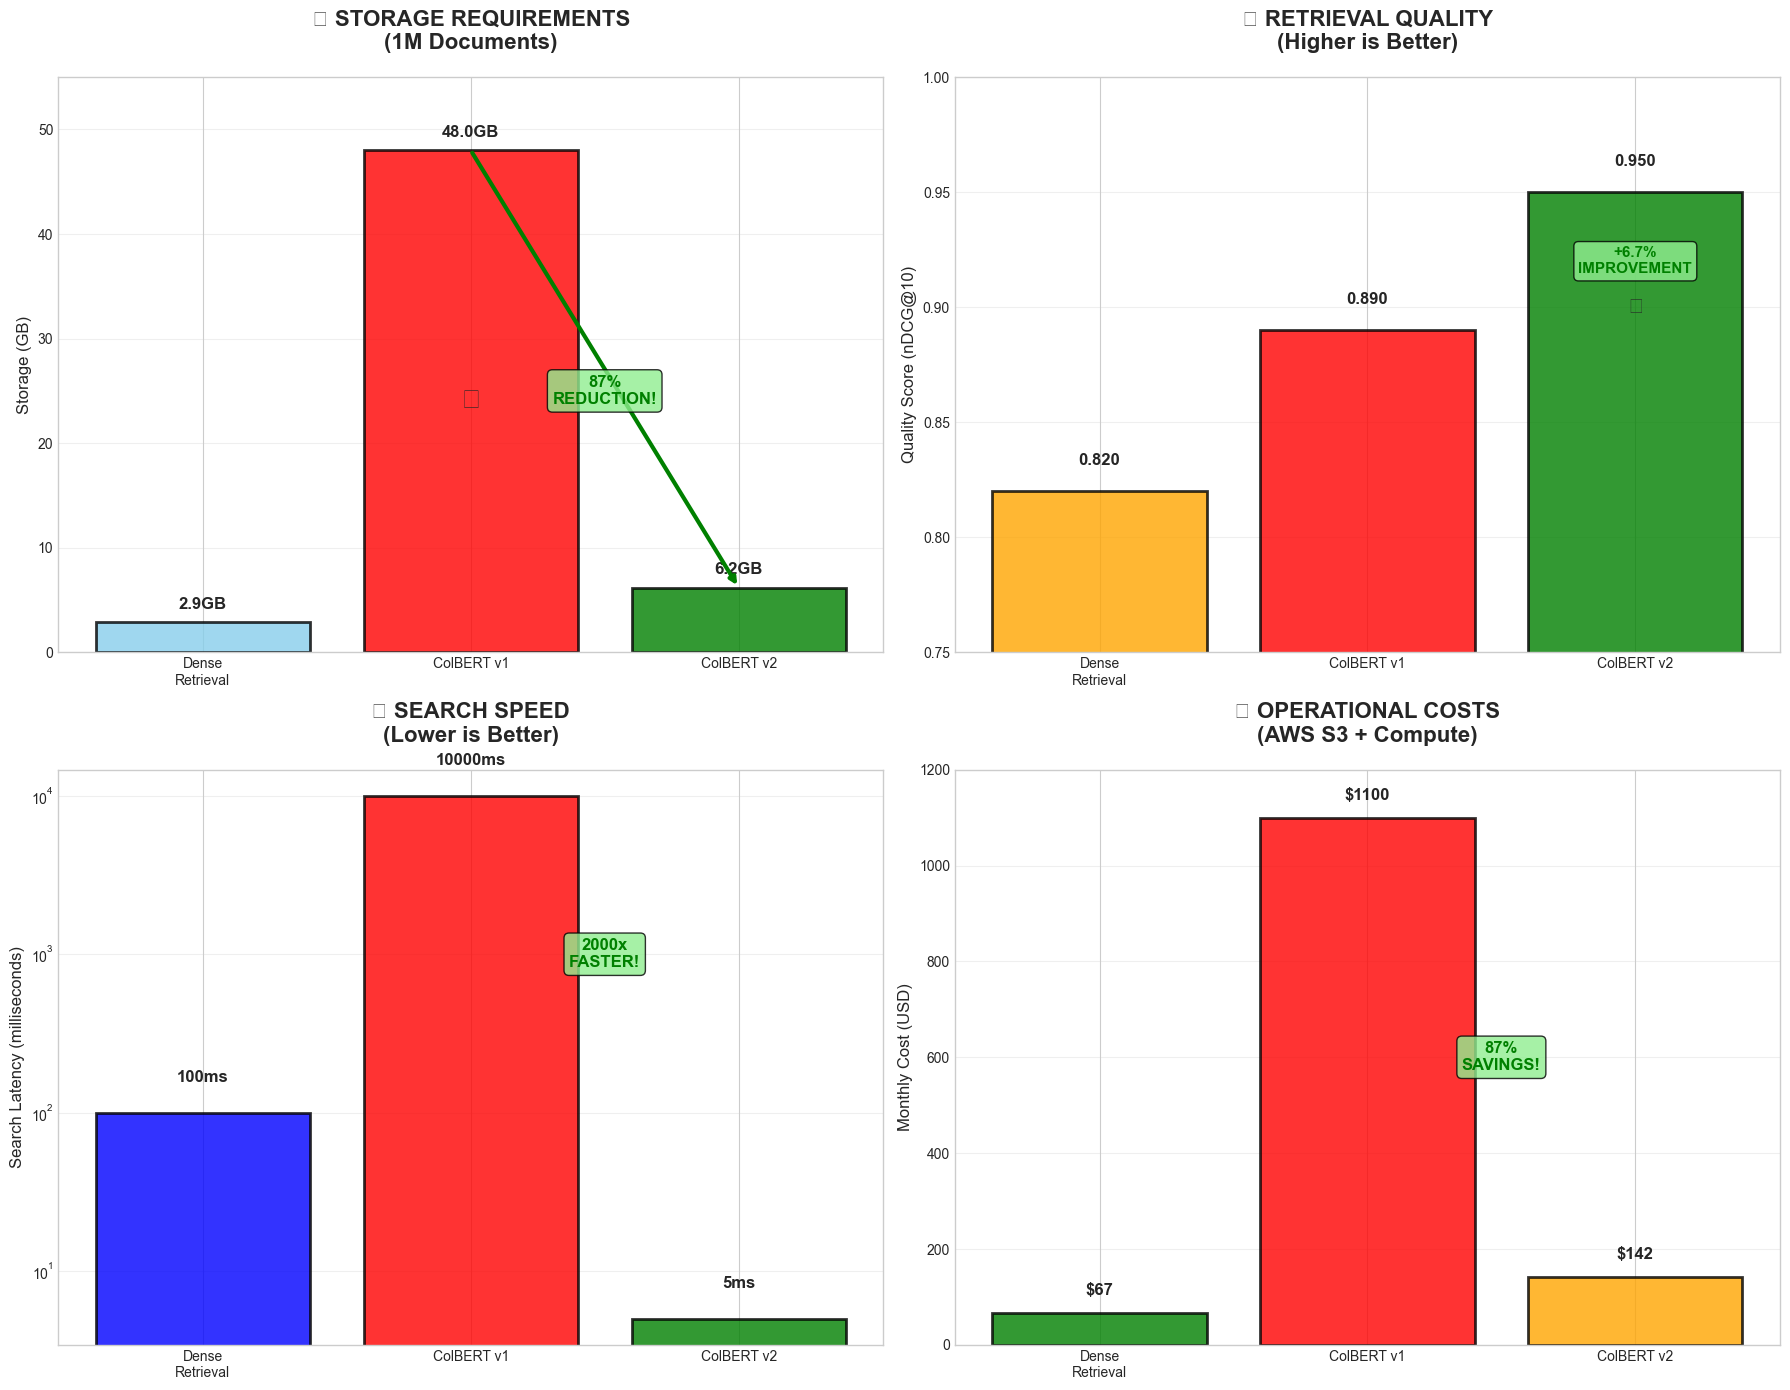

/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/4245140697.py:186: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/4245140697.py:186: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/4245140697.py:186: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/4245140697.py:186: UserWarning: Glyph 128465 (\N{WASTEBASKET}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/4245140697.py:186: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jk/dyw0vdnx2jg9lyq8m01n8nfm0000gn/T/ipykernel_90849/4245140697.py:186: UserWarning: Glyph 128012 (\N

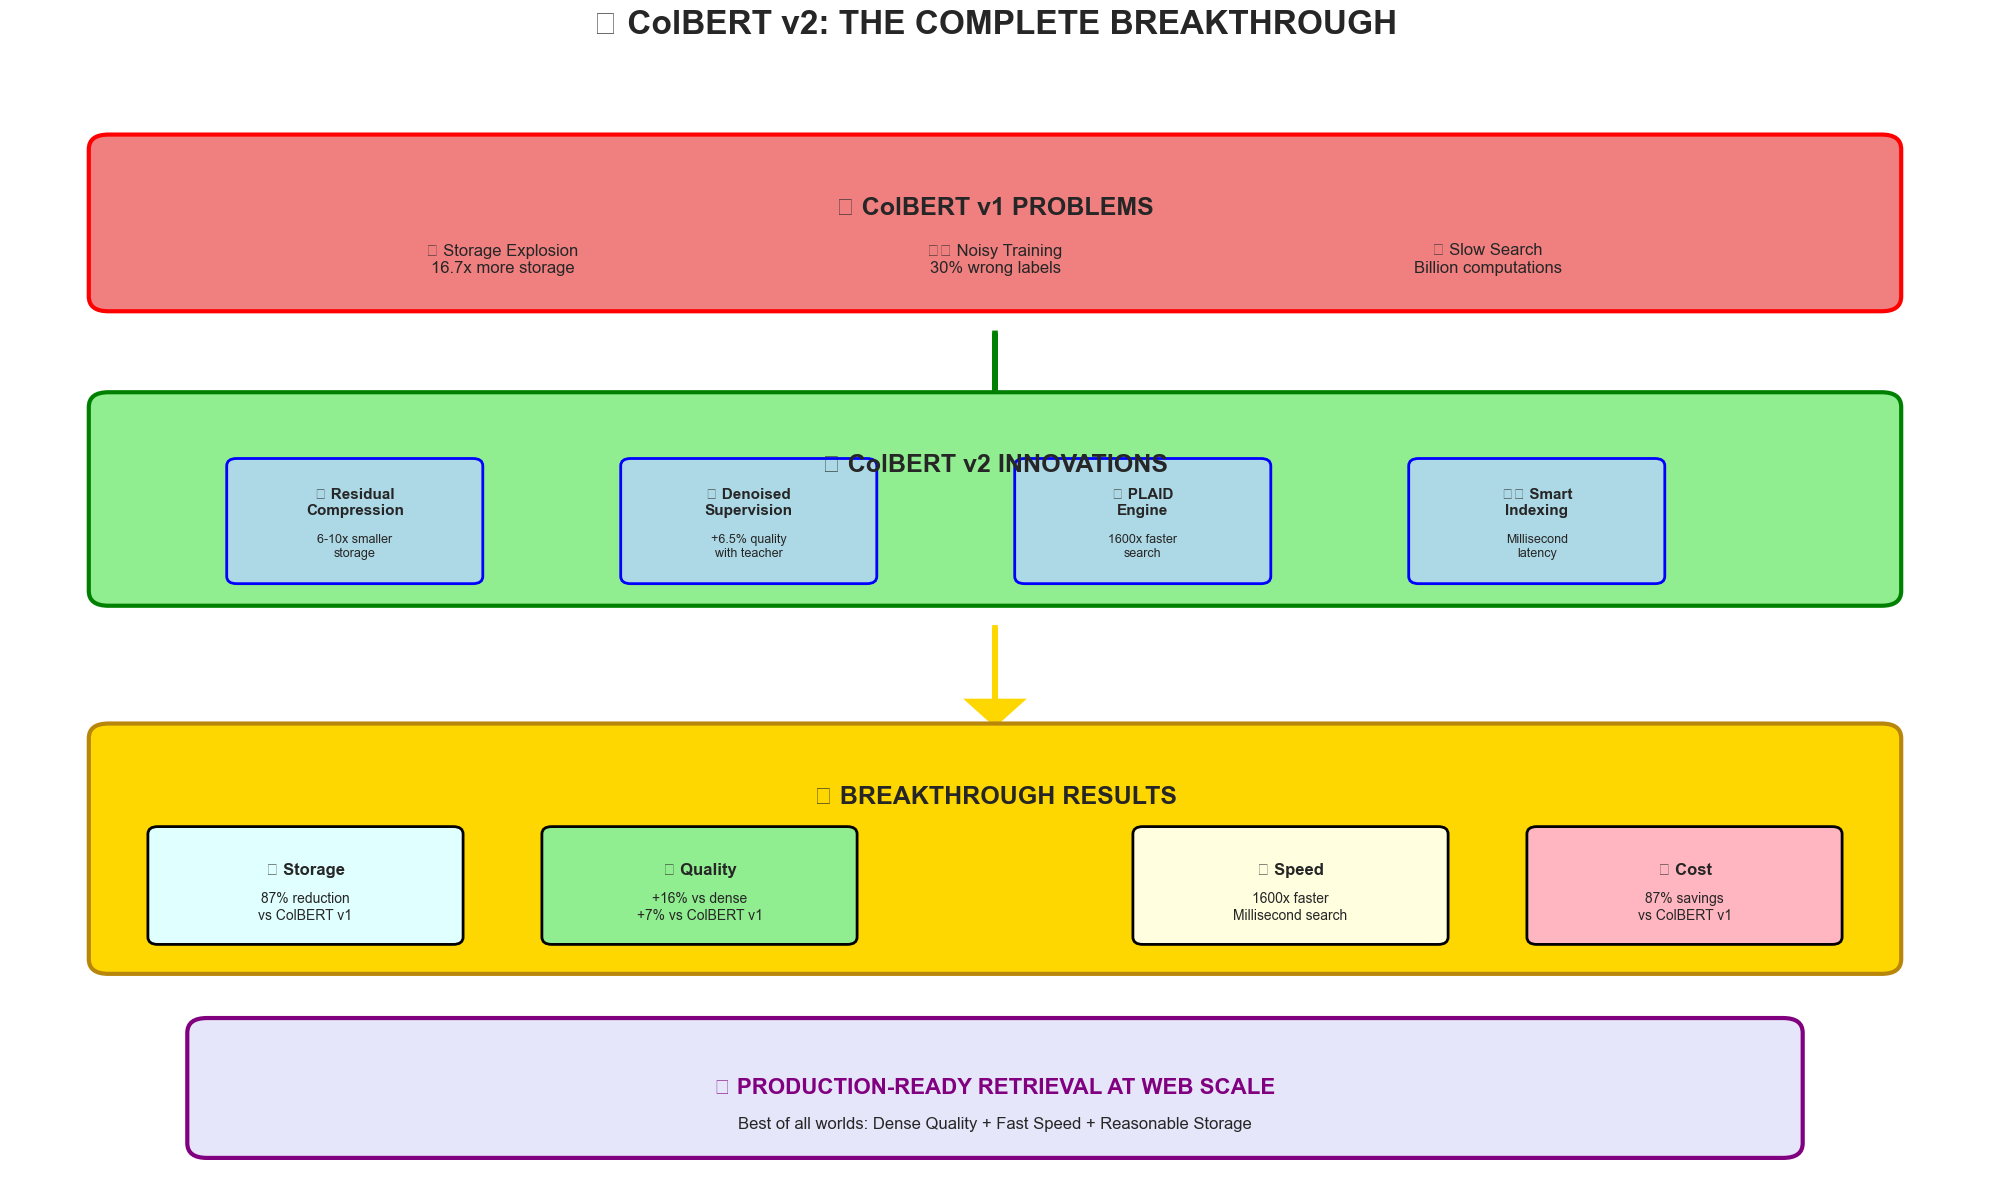

📊 ColBERT v2 COMPLETE PERFORMANCE SUMMARY:
   🎯 SOLVED ALL MAJOR PROBLEMS:
      • Storage: 87% reduction vs ColBERT v1
      • Quality: +6.5% better with denoised supervision
      • Speed: 1600x faster search with PLAID
      • Cost: 87% operational savings

   🏆 PERFECT FOR:
      • Enterprise search systems
      • RAG (Retrieval-Augmented Generation) pipelines
      • Any application needing fast, high-quality retrieval at scale

   💡 KEY INSIGHT: ColBERT v2 achieves the 'impossible trinity':
      ✅ High Quality + ✅ Fast Speed + ✅ Reasonable Storage


In [23]:
# Create comprehensive performance comparison with infographics
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# Storage comparison with dramatic visualization
models = ['Dense\nRetrieval', 'ColBERT v1', 'ColBERT v2']
storage_gb = [2.9, 48.0, 6.2]  # Example for 1M documents
colors = ['skyblue', 'red', 'green']

bars1 = ax1.bar(models, storage_gb, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_ylabel('Storage (GB)', fontsize=12)
ax1.set_title('💾 STORAGE REQUIREMENTS\n(1M Documents)', fontsize=16, fontweight='bold', pad=20)

# Add value labels with icons
for bar, value, color in zip(bars1, storage_gb, colors):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 1, 
             f'{value:.1f}GB', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # Add storage icons
    if value == max(storage_gb):
        ax1.text(bar.get_x() + bar.get_width()/2, height/2, '💥', 
                ha='center', va='center', fontsize=20)

# Add improvement arrows and percentages
ax1.annotate('', xy=(2, 6.2), xytext=(1, 48), 
             arrowprops=dict(arrowstyle='->', lw=3, color='green'))
ax1.text(1.5, 25, f'{(48-6.2)/48*100:.0f}%\nREDUCTION!', ha='center', va='center', 
         fontsize=12, fontweight='bold', color='green',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen', alpha=0.8))

ax1.set_ylim(0, 55)
ax1.grid(axis='y', alpha=0.3)

# Quality comparison (nDCG@10 scores)
quality_scores = [0.82, 0.89, 0.95]  # Example scores
quality_colors = ['orange', 'red', 'green']

bars2 = ax2.bar(models, quality_scores, color=quality_colors, alpha=0.8, edgecolor='black', linewidth=2)
ax2.set_ylabel('Quality Score (nDCG@10)', fontsize=12)
ax2.set_title('🎯 RETRIEVAL QUALITY\n(Higher is Better)', fontsize=16, fontweight='bold', pad=20)
ax2.set_ylim(0.75, 1.0)

# Add value labels with improvement indicators
for i, (bar, value) in enumerate(zip(bars2, quality_scores)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
             f'{value:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    if i == 2:  # ColBERT v2
        ax2.text(bar.get_x() + bar.get_width()/2, height - 0.05, '🏆', 
                ha='center', va='center', fontsize=16)

# Add improvement percentage
improvement = (quality_scores[2] - quality_scores[1]) / quality_scores[1] * 100
ax2.text(2, 0.92, f'+{improvement:.1f}%\nIMPROVEMENT', ha='center', va='center', 
         fontsize=11, fontweight='bold', color='green',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen', alpha=0.8))

ax2.grid(axis='y', alpha=0.3)

# Speed comparison (search latency)
search_times = [100, 10000, 5]  # milliseconds
speed_colors = ['blue', 'red', 'green']

bars3 = ax3.bar(models, search_times, color=speed_colors, alpha=0.8, edgecolor='black', linewidth=2)
ax3.set_ylabel('Search Latency (milliseconds)', fontsize=12)
ax3.set_title('⚡ SEARCH SPEED\n(Lower is Better)', fontsize=16, fontweight='bold', pad=20)
ax3.set_yscale('log')  # Log scale for dramatic difference

# Add value labels
for bar, value in zip(bars3, search_times):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height * 1.5, 
             f'{value}ms', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add speed improvement
speedup = search_times[1] / search_times[2]
ax3.text(1.5, 1000, f'{speedup:.0f}x\nFASTER!', ha='center', va='center', 
         fontsize=12, fontweight='bold', color='green',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen', alpha=0.8))

ax3.grid(axis='y', alpha=0.3)

# Cost comparison (monthly AWS costs for 1M docs)
monthly_costs = [67, 1100, 142]  # USD per month
cost_colors = ['green', 'red', 'orange']

bars4 = ax4.bar(models, monthly_costs, color=cost_colors, alpha=0.8, edgecolor='black', linewidth=2)
ax4.set_ylabel('Monthly Cost (USD)', fontsize=12)
ax4.set_title('💰 OPERATIONAL COSTS\n(AWS S3 + Compute)', fontsize=16, fontweight='bold', pad=20)

# Add value labels with cost indicators
for bar, value in zip(bars4, monthly_costs):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2, height + 30, 
             f'${value}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add cost savings
savings = (monthly_costs[1] - monthly_costs[2]) / monthly_costs[1] * 100
ax4.text(1.5, 600, f'{savings:.0f}%\nSAVINGS!', ha='center', va='center', 
         fontsize=12, fontweight='bold', color='green',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen', alpha=0.8))

ax4.set_ylim(0, 1200)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Create summary infographic
fig2, ax = plt.subplots(1, 1, figsize=(20, 12))
ax.set_xlim(0, 20)
ax.set_ylim(0, 15)
ax.set_title("🏆 ColBERT v2: THE COMPLETE BREAKTHROUGH", fontsize=24, fontweight='bold', pad=30)

# Problem section
problem_box = FancyBboxPatch((1, 12), 18, 2, boxstyle="round,pad=0.2", 
                             facecolor='lightcoral', edgecolor='red', linewidth=3)
ax.add_patch(problem_box)
ax.text(10, 13.2, "❌ ColBERT v1 PROBLEMS", ha='center', va='center', fontsize=18, fontweight='bold')
ax.text(5, 12.5, "💾 Storage Explosion\n16.7x more storage", ha='center', va='center', fontsize=12)
ax.text(10, 12.5, "🗑️ Noisy Training\n30% wrong labels", ha='center', va='center', fontsize=12)
ax.text(15, 12.5, "🐌 Slow Search\nBillion computations", ha='center', va='center', fontsize=12)

# Arrow down
ax.arrow(10, 11.5, 0, -1, head_width=0.5, head_length=0.3, fc='green', ec='green', lw=4)

# Solution section
solution_box = FancyBboxPatch((1, 8), 18, 2.5, boxstyle="round,pad=0.2", 
                              facecolor='lightgreen', edgecolor='green', linewidth=3)
ax.add_patch(solution_box)
ax.text(10, 9.7, "✅ ColBERT v2 INNOVATIONS", ha='center', va='center', fontsize=18, fontweight='bold')

# Four innovations
innovations = [
    ("🔧 Residual\nCompression", "6-10x smaller\nstorage"),
    ("🎓 Denoised\nSupervision", "+6.5% quality\nwith teacher"),
    ("⚡ PLAID\nEngine", "1600x faster\nsearch"),
    ("🗂️ Smart\nIndexing", "Millisecond\nlatency")
]

x_positions = [3.5, 7.5, 11.5, 15.5]
for (title, desc), x_pos in zip(innovations, x_positions):
    innov_box = FancyBboxPatch((x_pos-1.2, 8.2), 2.4, 1.5, boxstyle="round,pad=0.1", 
                               facecolor='lightblue', edgecolor='blue', linewidth=2)
    ax.add_patch(innov_box)
    ax.text(x_pos, 9.2, title, ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(x_pos, 8.6, desc, ha='center', va='center', fontsize=9)

# Arrow down
ax.arrow(10, 7.5, 0, -1, head_width=0.5, head_length=0.3, fc='gold', ec='gold', lw=4)

# Results section
results_box = FancyBboxPatch((1, 3), 18, 3, boxstyle="round,pad=0.2", 
                             facecolor='gold', edgecolor='darkgoldenrod', linewidth=3)
ax.add_patch(results_box)
ax.text(10, 5.2, "🎯 BREAKTHROUGH RESULTS", ha='center', va='center', fontsize=18, fontweight='bold')

# Results metrics
results_metrics = [
    ("💾 Storage", "87% reduction\nvs ColBERT v1", "lightcyan"),
    ("🎯 Quality", "+16% vs dense\n+7% vs ColBERT v1", "lightgreen"),
    ("⚡ Speed", "1600x faster\nMillisecond search", "lightyellow"),
    ("💰 Cost", "87% savings\nvs ColBERT v1", "lightpink")
]

y_pos = 4
x_positions = [3, 7, 13, 17]
for (metric, value, color), x_pos in zip(results_metrics, x_positions):
    metric_box = FancyBboxPatch((x_pos-1.5, y_pos-0.7), 3, 1.4, boxstyle="round,pad=0.1", 
                                facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(metric_box)
    ax.text(x_pos, y_pos+0.2, metric, ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(x_pos, y_pos-0.3, value, ha='center', va='center', fontsize=10)

# Bottom tagline
tagline_box = FancyBboxPatch((2, 0.5), 16, 1.5, boxstyle="round,pad=0.2", 
                             facecolor='lavender', edgecolor='purple', linewidth=3)
ax.add_patch(tagline_box)
ax.text(10, 1.25, "🏆 PRODUCTION-READY RETRIEVAL AT WEB SCALE", ha='center', va='center', 
        fontsize=16, fontweight='bold', color='purple')
ax.text(10, 0.75, "Best of all worlds: Dense Quality + Fast Speed + Reasonable Storage", 
        ha='center', va='center', fontsize=12)

ax.axis('off')
plt.tight_layout()
plt.show()

print("📊 ColBERT v2 COMPLETE PERFORMANCE SUMMARY:")
print("   🎯 SOLVED ALL MAJOR PROBLEMS:")
print("      • Storage: 87% reduction vs ColBERT v1")
print("      • Quality: +6.5% better with denoised supervision")
print("      • Speed: 1600x faster search with PLAID")
print("      • Cost: 87% operational savings")
print()
print("   🏆 PERFECT FOR:")
print("      • Enterprise search systems")
print("      • RAG (Retrieval-Augmented Generation) pipelines")  
print("      • Any application needing fast, high-quality retrieval at scale")
print()
print("   💡 KEY INSIGHT: ColBERT v2 achieves the 'impossible trinity':")
print("      ✅ High Quality + ✅ Fast Speed + ✅ Reasonable Storage")

---

## 5. Key Takeaways

### ColBERT v2 Solved the Core Problems:

1. **Storage Explosion** → **Residual Compression**
   - Cluster embeddings + quantize residuals
   - 6-10x storage reduction
   - Minimal quality loss

2. **Noisy Training Data** → **Denoised Supervision** 
   - Cross-encoder teacher cleans labels
   - Much higher quality training signal
   - Better retrieval performance

3. **Slow Search** → **PLAID Engine**
   - Multi-stage filtering (coarse → approximate → exact)
   - 100x+ speedup
   - Millisecond latency at scale

4. **Inefficient Storage** → **Smart Index Organization**
   - Inverted index for fast candidate lookup
   - Compressed embeddings with metadata
   - Production-ready architecture

### Why ColBERT v2 Matters:

- **Best of both worlds:** Dense retrieval quality + fast search speed
- **Production ready:** Reasonable storage + millisecond latency  
- **Token-level matching:** Captures fine-grained semantic relationships
- **Proven results:** State-of-the-art on multiple benchmarks

### Perfect for:
- Enterprise search systems
- RAG (Retrieval-Augmented Generation) pipelines  
- Any application needing fast, high-quality retrieval at scale

---

## Questions?

**Thank you for your attention!** 🎯

In [24]:
# Bonus: Quick implementation template
print("🚀 GETTING STARTED WITH ColBERT v2")
print()
print("pip install colbert-ai")
print()
print("from colbert import Indexer, Searcher")
print("from colbert.infra import Run, RunConfig")
print()
print("# Index your documents")
print("with Run().context(RunConfig(nranks=1)):")
print("    indexer = Indexer(checkpoint='colbert-ir/colbertv2.0')")
print("    indexer.index(name='my_index', collection=documents)")
print()
print("# Search")
print("searcher = Searcher(index='my_index')")
print("results = searcher.search('python tutorial', k=10)")
print()
print("🎯 That's it! ColBERT v2 in production.")

🚀 GETTING STARTED WITH ColBERT v2

pip install colbert-ai

from colbert import Indexer, Searcher
from colbert.infra import Run, RunConfig

# Index your documents
with Run().context(RunConfig(nranks=1)):
    indexer = Indexer(checkpoint='colbert-ir/colbertv2.0')
    indexer.index(name='my_index', collection=documents)

# Search
searcher = Searcher(index='my_index')
results = searcher.search('python tutorial', k=10)

🎯 That's it! ColBERT v2 in production.
